# 🩺 Diabetic Retinopathy Grading — v13 — Fundus Ensemble v3 + Streamlit Deploy
## EfficientNetV2-S + GeM + DeepCORAL | Fundus Ensemble: MobileNetV3 + ConvNeXt-22k + ConvNeXt-12k
### QWK-Optimised | Temperature-Calibrated | External Validation | Zero Runtime Errors

> ⚠️ **RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT**

| Component | Detail |
|-----------|--------|
| **Backbone** | EfficientNetV2-S (tf_efficientnetv2_s, 21M params) |
| **Device** | Apple Silicon MPS (no CUDA, no Colab) |
| **Pooling** | Generalized Mean (GeM, learnable p) |
| **Loss** | 0.5×CE(label_smooth=0.10) + 0.5×Focal(γ=2) [class-weighted] |
| **Domain Adapt** | DeepCORAL (batch covariance alignment, λ=0.1) |
| **Augmentation** | CLAHE + 360° rot + flips + HueSaturation + CoarseDropout |
| **Anti-Overfit** | Dropout(0.4) + LabelSmooth(0.10) + EarlyStop(pat=8) |
| **Calibration** | Temperature Scaling (post-hoc, LBFGS, ECE reported) |
| **Metrics** | QWK · Acc · F1 · AUROC · Sensitivity · Specificity · ECE |
| **Validation** | Internal (80/10/10 split) + External (domain-shifted) |
| **Dataset** | APTOS 2019 (primary) |

### ▶️ Execution Order
Run **Cell 0** (env check) → **Cell 1** (optional reset) → **Cell 2** (imports) → all subsequent cells in order.
On **kernel restart**: run only Cell 2 — `_master_recover()` rebuilds all state from disk.

In [1]:
# ═══════════════════════════════════════════════════════════════
#  DR GRADING v9 — Cell 0: Environment Check
#  Mac MPS GPU only (no CUDA, no Colab).
#  Every cell MUST print verifiable output.
# ═══════════════════════════════════════════════════════════════
import sys, platform, subprocess
import torch

print("=" * 62)
print("  ENVIRONMENT — DR Grading v9 (Mac MPS Edition)")
print("=" * 62)
print(f"  OS          : {platform.system()} {platform.release()}")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  PyTorch     : {torch.__version__}")
print(f"  MPS avail   : {torch.backends.mps.is_available()}")
print(f"  MPS built   : {torch.backends.mps.is_built()}")

if torch.backends.mps.is_available():
    _x = torch.randn(64, 64, device='mps')
    _s = (_x @ _x.T).sum().item()
    del _x
    print(f"  MPS test    : ✅  (sum={_s:.1f})")
    print("  DEVICE      : MPS ✅")
else:
    print("  DEVICE      : CPU ⚠️  (MPS not available — training will be slow)")

# Check required packages
_pkgs = ["timm", "albumentations", "cv2", "sklearn", "tqdm", "pandas",
         "numpy", "matplotlib", "PIL"]
_missing = []
for _p in _pkgs:
    try: __import__(_p); print(f"  {_p:<20}: ✅")
    except ImportError: print(f"  {_p:<20}: ❌ MISSING"); _missing.append(_p)

if _missing:
    print(f"\n⚠️  Missing packages: {_missing}")
    print("   Run: pip install timm albumentations opencv-python scikit-learn tqdm pandas")
else:
    print("\n✅ All packages available — ready to run")
print("=" * 62)

  ENVIRONMENT — DR Grading v9 (Mac MPS Edition)
  OS          : Darwin 25.0.0
  Python      : 3.9.6
  PyTorch     : 2.8.0
  MPS avail   : True
  MPS built   : True
  MPS test    : ✅  (sum=3735.6)
  DEVICE      : MPS ✅
  timm                : ✅


INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.8 (you have 1.4.11). Upgrade using: pip install --upgrade albumentations


  albumentations      : ✅
  cv2                 : ✅
  sklearn             : ✅
  tqdm                : ✅
  pandas              : ✅
  numpy               : ✅
  matplotlib          : ✅
  PIL                 : ✅

✅ All packages available — ready to run


In [2]:
# ═══════════════════════════════════════════════════════════════
#  Cell 2: IMPORTS · DEVICE · SEEDS · STATE MANAGEMENT
#  Mac MPS GPU only — no CUDA, no Colab references.
# ═══════════════════════════════════════════════════════════════
import os, sys, io, json, gc, time, random, shutil, warnings
import zipfile, hashlib
from pathlib import Path
from copy import deepcopy
from contextlib import nullcontext
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from tqdm.auto import tqdm
import scipy.stats as stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, cohen_kappa_score,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.preprocessing import label_binarize
from IPython.display import display, Image as IPyImage

try:
    from pytorch_grad_cam import GradCAMPlusPlus
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRADCAM_AVAILABLE = True
except ImportError:
    GRADCAM_AVAILABLE = False
    print("⚠️  pytorch_grad_cam not installed — Grad-CAM++ will be skipped")

warnings.filterwarnings("ignore")

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = "mps"
    torch.mps.manual_seed(42)
    print(f"🍎 Apple Silicon MPS — device={DEVICE}")
else:
    DEVICE = "cpu"
    print(f"💻 CPU only — device={DEVICE}")

USE_AMP    = False          # MPS does not support torch.amp reliably
_AMP_CTX   = nullcontext()  # always nullcontext — used throughout
NUM_WORKERS = 0             # ✅ FIX: must be 0 on macOS/MPS (spawn restriction)
PIN_MEMORY  = False         # ✅ FIX: pin_memory=True crashes on MPS

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything()

# ── Global constants ──────────────────────────────────────────────────────────
GRADE_MAP    = {0:"No DR",1:"Mild DR",2:"Moderate DR",3:"Severe DR",4:"Proliferative DR"}
GRADE_COLORS = ["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad"]
NUM_CLASSES  = 5
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Directory layout ──────────────────────────────────────────────────────────
BASE_DIR     = Path(os.environ.get("BASE_DIR", str(Path.home() / "DR_data")))
ARTIFACT_DIR = BASE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ── Safe load ─────────────────────────────────────────────────────────────────
def _safe_load(path, map_location=None):
    loc = map_location or DEVICE
    try:    return torch.load(path, map_location=loc, weights_only=False)
    except: return torch.load(path, map_location="cpu", weights_only=False)

# ── State helpers ─────────────────────────────────────────────────────────────
STATE_FILE = ARTIFACT_DIR / "_resume_state.json"
def _st_load() -> dict:
    try:    return json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}
    except: return {}
def _st_save(key, value):
    s = _st_load(); s[key] = value
    STATE_FILE.write_text(json.dumps(s, indent=2))
def _st_done(key) -> bool:
    return bool(_st_load().get(key, False))
def _st_get(key, default=None):
    return _st_load().get(key, default)

# ── CellState ─────────────────────────────────────────────────────────────────
class _CellState:
    def __init__(self, key):
        self.key  = key
        self.done = _st_done(key)
    def finish(self, success=True):
        _st_save(self.key, success); self.done = success
    @staticmethod
    def show_image(fname, figsize=(12,6)):
        p = ARTIFACT_DIR / fname
        if p.exists():
            img = plt.imread(str(p))
            fig, ax = plt.subplots(figsize=figsize)
            ax.imshow(img); ax.axis("off"); plt.tight_layout(); plt.show()
        else:
            print(f"⚠️  {fname} not found")

# ── Master recovery ───────────────────────────────────────────────────────────
def _master_recover():
    g = globals()
    for k, v in [
        ("DEVICE", DEVICE), ("USE_AMP", False), ("NUM_WORKERS", 0),
        ("PIN_MEMORY", False), ("SEED", 42), ("GRADE_MAP", GRADE_MAP),
        ("GRADE_COLORS", GRADE_COLORS), ("NUM_CLASSES", 5),
        ("IMAGENET_MEAN", IMAGENET_MEAN), ("IMAGENET_STD", IMAGENET_STD),
        ("BASE_DIR", BASE_DIR), ("ARTIFACT_DIR", ARTIFACT_DIR),
        ("_AMP_CTX", nullcontext()),
    ]:
        g.setdefault(k, v)

    # ✅ FIX: IMG_SIZE default 1024; batch sizes correct per resolution
    img_size = _st_get("IMG_SIZE", int(os.environ.get("IMG_SIZE", 1024)))
    g.setdefault("IMG_SIZE", img_size)
    g.setdefault("BACKBONE", "tf_efficientnetv2_s")
    if img_size >= 1024:  bs, ga = 4, 4
    elif img_size >= 512: bs, ga = 8, 2
    else:                 bs, ga = 16, 1
    g.setdefault("BATCH_SIZE", bs)
    g.setdefault("GRAD_ACCUM", ga)

    sp = ARTIFACT_DIR / "splits.parquet"
    if "df_tr" not in g and sp.exists():
        sc = pd.read_parquet(sp)
        def _fx(d):
            d = d.copy()
            if "image_path" not in d.columns:
                d["image_path"] = d.apply(
                    lambda r: str(BASE_DIR/"aptos2019"/"train_images"/f"{r['id_code']}.png"), axis=1)
            if "grade_label" not in d.columns:
                d["grade_label"] = d["diagnosis"].map(GRADE_MAP)
            return d
        g["df_tr"] = _fx(sc[sc["_split"]=="train"].drop("_split",axis=1).reset_index(drop=True))
        g["df_va"] = _fx(sc[sc["_split"]=="val"  ].drop("_split",axis=1).reset_index(drop=True))
        g["df_te"] = _fx(sc[sc["_split"]=="test" ].drop("_split",axis=1).reset_index(drop=True))
        print(f"  📂 [RECOVER] splits: tr={len(g['df_tr'])} va={len(g['df_va'])} te={len(g['df_te'])}")

    _blank = {k:[] for k in ["train_loss","train_acc","val_loss","val_acc","val_qwk","val_qwk_ext","val_f1","coral_loss"]}
    if "history" not in g:
        g["history"] = dict(_blank)
        for ck in [ARTIFACT_DIR/"best_model.pt", ARTIFACT_DIR/"last_epoch.pt"]:
            if ck.exists():
                try:
                    d = _safe_load(ck, "cpu")
                    if d.get("history", {}).get("train_loss"):
                        g["history"] = d["history"]
                        for k in ["coral_loss","val_qwk_ext","val_f1"]:
                            g["history"].setdefault(k, [0.0]*len(g["history"]["train_loss"]))
                        print(f"  📂 [RECOVER] history from {ck.name}")
                        break
                except: pass

    g.setdefault("best_val_qwk",  _st_get("best_val_qwk",  -1.0))
    g.setdefault("best_val_loss", _st_get("best_val_loss", float("inf")))
    g.setdefault("best_epoch",    _st_get("best_epoch",    0))
    print("  ✅ Master state recovery complete")

_master_recover()

print(f"\n✅ Cell 2 complete")
print(f"   PyTorch {torch.__version__} | timm {timm.__version__}")
print(f"   Device    : {DEVICE.upper()}  |  AMP: OFF  |  Workers: {NUM_WORKERS}")
print(f"   IMG_SIZE  : {IMG_SIZE}  |  BATCH_SIZE: {BATCH_SIZE}  |  GRAD_ACCUM: {GRAD_ACCUM}")
print(f"   Artifact  : {ARTIFACT_DIR}")


🍎 Apple Silicon MPS — device=mps
  📂 [RECOVER] splits: tr=2671 va=334 te=334
  📂 [RECOVER] history from best_model.pt
  ✅ Master state recovery complete

✅ Cell 2 complete
   PyTorch 2.8.0 | timm 1.0.27
   Device    : MPS  |  AMP: OFF  |  Workers: 0
   IMG_SIZE  : 1024  |  BATCH_SIZE: 4  |  GRAD_ACCUM: 4
   Artifact  : /Users/gokulnathan/DR_data/artifacts


In [3]:
# ── FORCE IMG_SIZE → 1024 in state file (run once, then re-run Cell 2) ──────
import json
from pathlib import Path

_state_file = Path.home() / "DR_data" / "artifacts" / "_resume_state.json"
_s = json.loads(_state_file.read_text()) if _state_file.exists() else {}
_s["IMG_SIZE"] = 1024
_state_file.write_text(json.dumps(_s, indent=2))
print(f"✅ IMG_SIZE forced to 1024 in state file")
print(f"   Now re-run Cell 2")

✅ IMG_SIZE forced to 1024 in state file
   Now re-run Cell 2


In [4]:
# ═══════════════════════════════════════════════════════════════
#  Cell 3: KAGGLE API SETUP
# ═══════════════════════════════════════════════════════════════
kaggle_dir  = Path.home() / ".kaggle"
kaggle_json = kaggle_dir / "kaggle.json"
kaggle_dir.mkdir(exist_ok=True)

if kaggle_json.exists():
    try:
        creds = json.loads(kaggle_json.read_text())
        os.chmod(kaggle_json, 0o600)
        print(f"✅ Kaggle auth OK — user: {creds.get('username','?')}")
    except Exception as e:
        print(f"⚠️  kaggle.json invalid: {e}")
else:
    u = os.environ.get("KAGGLE_USERNAME")
    k = os.environ.get("KAGGLE_KEY")
    if u and k:
        kaggle_json.write_text(json.dumps({"username": u, "key": k}))
        os.chmod(kaggle_json, 0o600)
        print(f"✅ Kaggle credentials set from env (user: {u})")
    else:
        local = Path("kaggle.json")
        if local.exists():
            shutil.copy(local, kaggle_json)
            os.chmod(kaggle_json, 0o600)
            print("✅ Copied kaggle.json from working directory")
        else:
            print("⚠️  kaggle.json NOT found.")
            print("   Options:")
            print("   1. Place kaggle.json in ~/.kaggle/")
            print("   2. Set env vars: KAGGLE_USERNAME and KAGGLE_KEY")
            print("   3. Place kaggle.json in the current working directory")

import subprocess as _sp
r = _sp.run(["kaggle", "--version"], capture_output=True, text=True)
print(f"Kaggle CLI: {r.stdout.strip() if r.returncode == 0 else '❌ not found — pip install kaggle'}")

✅ Kaggle auth OK — user: gokulnathanganesan
Kaggle CLI: Kaggle API 1.7.4.5


In [5]:
# ═══════════════════════════════════════════════════════════════
#  Cell 4: APTOS 2019 DOWNLOAD
#  Downloads APTOS 2019 blindness detection dataset from Kaggle.
# ═══════════════════════════════════════════════════════════════
import subprocess as _sp, zipfile

_CS = _CellState("step04_download")

DS_DIR  = BASE_DIR / "aptos2019"
IMG_DIR = DS_DIR / "train_images"
CSV_PATH= DS_DIR / "train.csv"
DS_DIR.mkdir(parents=True, exist_ok=True)

_MIN_IMGS = 3000

def _count_imgs():
    return len(list(IMG_DIR.glob("*.png"))) if IMG_DIR.exists() else 0

if _count_imgs() >= _MIN_IMGS and CSV_PATH.exists():
    n = _count_imgs()
    print(f"✅ [RESUME] APTOS 2019 already present — {n:,} images")
    df_check = pd.read_csv(CSV_PATH)
    print(f"   CSV rows: {len(df_check):,}")
    print(f"   Grades  : {dict(df_check['diagnosis'].value_counts().sort_index())}")
else:
    _CS.finish(False)  # reset so we rerun
    print("📥 Downloading APTOS 2019...")
    _zip = DS_DIR / "aptos2019-blindness-detection.zip"
    if not _zip.exists():
        ret = os.system(f"kaggle competitions download -c aptos2019-blindness-detection -p {DS_DIR}")
        if ret != 0:
            print("❌ Download failed. Check Kaggle credentials (Cell 3).")
            raise RuntimeError("APTOS 2019 download failed")
    if not IMG_DIR.exists() or _count_imgs() < _MIN_IMGS:
        print("📂 Extracting...")
        with zipfile.ZipFile(_zip, "r") as z:
            z.extractall(DS_DIR)
    n = _count_imgs()
    df_check = pd.read_csv(CSV_PATH)
    print(f"✅ APTOS 2019 ready — {n:,} images, {len(df_check):,} CSV rows")
    print(f"   Grades: {dict(df_check['diagnosis'].value_counts().sort_index())}")
    _CS.finish(True)

✅ [RESUME] APTOS 2019 already present — 3,662 images
   CSV rows: 3,662
   Grades  : {0: 1805, 1: 370, 2: 999, 3: 193, 4: 295}


In [6]:
# ═══════════════════════════════════════════════════════════════
#  Cell 5: DATA LOADING · LABEL NORMALISATION · QC
#  Deduplication via MD5 hash + blur quality filter.
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step05_merge")
_MERGED_CACHE = ARTIFACT_DIR / "df_merged.parquet"

if _CS.done and _MERGED_CACHE.exists():
    df_all = pd.read_parquet(_MERGED_CACHE)
    print(f"✅ [RESUME] Merged dataset: {len(df_all):,} samples")
else:
    DS_DIR  = BASE_DIR / "aptos2019"
    IMG_DIR = DS_DIR / "train_images"
    CSV_PATH= DS_DIR / "train.csv"

    _df = pd.read_csv(CSV_PATH)
    _df = _df.rename(columns={"id_code":"id_code","diagnosis":"diagnosis"})
    _df["diagnosis"] = _df["diagnosis"].astype(int).clip(0, 4)
    _df["source"]    = "aptos2019"
    _df["image_path"]= _df["id_code"].apply(
        lambda x: str(IMG_DIR / f"{x}.png"))

    # Remove missing images
    _exist = _df["image_path"].apply(lambda p: Path(p).exists())
    n_miss = (~_exist).sum()
    if n_miss > 0:
        print(f"  Removed {n_miss} missing image paths")
    _df = _df[_exist].reset_index(drop=True)
    print(f"  Loaded {len(_df):,} valid samples from APTOS 2019")

    # ── Deduplication via MD5 ─────────────────────────────────────────────────
    print("\nDeduplicating...")
    def _fingerprint(path):
        try:
            sz = os.stat(path).st_size
            with open(path, "rb") as f:
                head = f.read(8192)
            return f"{sz}_{hashlib.md5(head).hexdigest()}"
        except:
            return str(random.random())

    with ThreadPoolExecutor(max_workers=4) as ex:
        fps = list(tqdm(ex.map(_fingerprint, _df["image_path"]),
                        total=len(_df), desc="Fingerprinting"))
    _df["_fp"] = fps
    n_before = len(_df)
    _df = _df.drop_duplicates(subset="_fp").drop(columns=["_fp"]).reset_index(drop=True)
    print(f"  Removed {n_before - len(_df)} duplicates → {len(_df):,} unique")

    # ── Blur QC ───────────────────────────────────────────────────────────────
    print("\nBlur quality check...")
    def _blur_score(path):
        try:
            img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
            if img is None: return 0.0
            h, w = img.shape
            roi = img[h//4:3*h//4, w//4:3*w//4]
            return float(cv2.Laplacian(roi, cv2.CV_64F).var())
        except: return 0.0

    with ThreadPoolExecutor(max_workers=4) as ex:
        blur_scores = list(tqdm(ex.map(_blur_score, _df["image_path"]),
                                total=len(_df), desc="Blur QC"))
    _df["blur_score"] = blur_scores

    BLUR_THR = 5.0
    _blurry  = _df["blur_score"] < BLUR_THR
    n_blur   = _blurry.sum()
    if n_blur > 0.50 * len(_df):
        print(f"⚠️  {n_blur} blurry but >50% total — keeping all")
    elif n_blur > 0:
        _df = _df[~_blurry].reset_index(drop=True)
        print(f"  Removed {n_blur} blurry images → {len(_df):,}")

    _df["grade_label"] = _df["diagnosis"].map(GRADE_MAP)
    _df["binary"]      = (_df["diagnosis"] >= 2).astype(int)

    df_all = _df
    df_all.to_parquet(_MERGED_CACHE, index=False)
    print(f"\n💾 Merged dataset saved")
    _CS.finish(True)

# Always print distribution
print(f"\n📊 Class distribution ({len(df_all):,} total):")
for g_id, cnt in df_all["diagnosis"].value_counts().sort_index().items():
    bar = "█" * (cnt // 100)
    print(f"  Grade {g_id} ({GRADE_MAP[g_id]:<25}): {cnt:5d}  {bar}")
imr = df_all["diagnosis"].value_counts().max() / df_all["diagnosis"].value_counts().min()
print(f"  Imbalance ratio: {imr:.1f}×")
print(f"  DR present (≥2): {(df_all['diagnosis']>=2).sum():,} ({(df_all['diagnosis']>=2).mean()*100:.1f}%)")

✅ [RESUME] Merged dataset: 3,339 samples

📊 Class distribution (3,339 total):
  Grade 0 (No DR                    ):  1787  █████████████████
  Grade 1 (Mild DR                  ):   328  ███
  Grade 2 (Moderate DR              ):   799  ███████
  Grade 3 (Severe DR                ):   170  █
  Grade 4 (Proliferative DR         ):   255  ██
  Imbalance ratio: 10.5×
  DR present (≥2): 1,224 (36.7%)


In [7]:
# ═══════════════════════════════════════════════════════════════
#  Cell 6: EXPLORATORY DATA ANALYSIS
#  Class distribution · sample images per grade
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step06_eda")
_EDA_FLAG = ARTIFACT_DIR / "eda_plot.png"

if _CS.done and _EDA_FLAG.exists():
    print("✅ [RESUME] EDA plot already saved — displaying:")
    _CellState.show_image("eda_plot.png", figsize=(18, 5))
else:
    counts = df_all["diagnosis"].value_counts().sort_index()
    pcts   = counts / counts.sum() * 100

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Bar chart
    bars = axes[0].bar([f"G{i}" for i in counts.index], counts.values,
                       color=GRADE_COLORS, edgecolor="black", linewidth=0.8)
    for b, v in zip(bars, counts.values):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5,
                     str(v), ha="center", va="bottom", fontweight="bold", fontsize=10)
    axes[0].set_title("Class Distribution (Count)", fontweight="bold")
    axes[0].set_ylabel("Count"); axes[0].set_xlabel("DR Grade")
    axes[0].grid(axis="y", alpha=0.3)

    # Pie chart
    axes[1].pie(counts.values,
                labels=[f"G{i}\n{GRADE_MAP[i][:10]}" for i in counts.index],
                colors=GRADE_COLORS, autopct="%1.1f%%", startangle=90)
    axes[1].set_title("Class Distribution (%)", fontweight="bold")

    # Imbalance ratio
    max_c  = counts.max()
    ratios = [max_c / c for c in counts.values]
    axes[2].barh([f"G{i}" for i in counts.index], ratios,
                 color=GRADE_COLORS, edgecolor="black")
    for i, r in enumerate(ratios):
        axes[2].text(r+0.05, i, f"{r:.1f}×", va="center", fontsize=10)
    axes[2].set_title("Imbalance Ratio (max/each)", fontweight="bold")
    axes[2].set_xlabel("Ratio")
    axes[2].axvline(x=1, color="k", linestyle="--", alpha=0.4)

    plt.suptitle(f"APTOS 2019 EDA — {len(df_all):,} samples", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(_EDA_FLAG, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n✅ EDA saved → {_EDA_FLAG}")

    # Binary breakdown
    dr_n   = (df_all["diagnosis"] >= 2).sum()
    no_dr  = len(df_all) - dr_n
    print(f"\n  Referrable DR (Grade≥2): {dr_n:,} ({dr_n/len(df_all)*100:.1f}%)")
    print(f"  Non-referrable (0–1)  : {no_dr:,} ({no_dr/len(df_all)*100:.1f}%)")
    _CS.finish(True)

✅ [RESUME] EDA plot already saved — displaying:


In [8]:
# ═══════════════════════════════════════════════════════════════
#  Cell 7: PREPROCESSING PIPELINE
#  CLAHE (LAB) + Retinal Crop + Resize  — cache-aware
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step07_preproc")

if _CS.done and "preprocess_fundus" in dir():
    print("✅ [RESUME] preprocess_fundus already defined")
else:
    _CLAHE_OBJ = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def _clahe_lab(rgb: np.ndarray) -> np.ndarray:
        """Apply CLAHE on LAB L-channel only — preserves colour fidelity."""
        lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = _CLAHE_OBJ.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    def _make_retinal_mask(rgb: np.ndarray) -> np.ndarray:
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        return cv2.morphologyEx(cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k), cv2.MORPH_OPEN, k)

    def _crop_retinal(rgb: np.ndarray, pad: int = 10) -> np.ndarray:
        """Crop dark borders — retains full retinal disc."""
        mask = _make_retinal_mask(rgb)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return rgb
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        x  = max(0, x - pad);  y  = max(0, y - pad)
        x2 = min(rgb.shape[1], x + w + 2 * pad)
        y2 = min(rgb.shape[0], y + h + 2 * pad)
        crop = rgb[y:y2, x:x2]
        return crop if crop.size > 0 else rgb

    def preprocess_fundus(path, target_size=384, cache_dir=None) -> np.ndarray:
        """Full pipeline: load → CLAHE → retinal crop → resize. Cache-aware."""
        p = Path(path)
        if cache_dir:
            cached = Path(cache_dir) / (p.stem + ".png")
            if cached.exists():
                img = cv2.imread(str(cached))
                if img is not None:
                    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.imread(str(path))
        if img is None:
            # Return blank image rather than crashing
            return np.zeros((target_size, target_size, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = _clahe_lab(img)
        img = _crop_retinal(img)
        img = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA)
        if cache_dir:
            Path(cache_dir).mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(Path(cache_dir) / (p.stem + ".png")),
                        cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        return img

    IMG_SIZE   = _st_get("IMG_SIZE", int(os.environ.get("IMG_SIZE", 1024)))
    _CACHE_DIR = BASE_DIR / f"cache_{IMG_SIZE}"
    _CACHE_DIR.mkdir(parents=True, exist_ok=True)

    print(f"✅ preprocess_fundus defined — target_size={IMG_SIZE}px")
    print(f"   Preprocessing: CLAHE (LAB L-channel) → retinal crop → resize")
    print(f"   Cache dir: {_CACHE_DIR}")
    _CS.finish(True)

IMG_SIZE   = _st_get("IMG_SIZE", int(os.environ.get("IMG_SIZE", 1024)))
_CACHE_DIR = BASE_DIR / f"cache_{IMG_SIZE}"
_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Show sample preprocessed images per grade
_fig, _axes = plt.subplots(1, 5, figsize=(18, 4))
for _gi in range(5):
    _samp = df_all[df_all["diagnosis"] == _gi]
    if len(_samp) == 0: continue
    _row  = _samp.iloc[0]
    try:
        _img = preprocess_fundus(_row["image_path"], target_size=IMG_SIZE, cache_dir=_CACHE_DIR)
        _axes[_gi].imshow(_img)
    except Exception as _e:
        _axes[_gi].text(0.5, 0.5, str(_e)[:30], ha="center", transform=_axes[_gi].transAxes)
    _axes[_gi].set_title(f"G{_gi}: {GRADE_MAP[_gi][:12]}", fontsize=9, color=GRADE_COLORS[_gi])
    _axes[_gi].axis("off")
plt.suptitle(f"Sample Preprocessed Images (CLAHE+Crop, {IMG_SIZE}px)", fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR/"sample_images.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Sample images saved")

✅ preprocess_fundus defined — target_size=1024px
   Preprocessing: CLAHE (LAB L-channel) → retinal crop → resize
   Cache dir: /Users/gokulnathan/DR_data/cache_1024
✅ Sample images saved


In [9]:
# ═══════════════════════════════════════════════════════════════
#  Cell 8: PRE-CACHE ALL IMAGES
#  Run preprocessing on all images and save to cache_dir.
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step08_cache")
_N_EXPECTED = len(df_all)
_N_CACHED   = len(list(_CACHE_DIR.glob("*.png")))

if _CS.done and _N_CACHED >= _N_EXPECTED * 0.95:
    print(f"✅ [RESUME] {_N_CACHED:,}/{_N_EXPECTED:,} images already cached")
else:
    def _cache_one(row):
        try:
            preprocess_fundus(row["image_path"], target_size=IMG_SIZE, cache_dir=_CACHE_DIR)
            return True
        except:
            return False

    print(f"Caching {_N_EXPECTED:,} images at {IMG_SIZE}px (4 threads)...")
    rows = [r for _, r in df_all.iterrows()]
    with ThreadPoolExecutor(max_workers=4) as ex:
        results = list(tqdm(ex.map(_cache_one, rows), total=len(rows), desc="Caching"))

    n_ok   = sum(results)
    n_fail = len(results) - n_ok
    print(f"✅ Cached: {n_ok:,}  Failed: {n_fail}")
    if n_fail > 0:
        print(f"   ⚠️  {n_fail} images failed to cache (will use raw paths as fallback)")
    _CS.finish(True)

_N_CACHED = len(list(_CACHE_DIR.glob("*.png")))
print(f"   Cache dir: {_CACHE_DIR}")
print(f"   Cached files: {_N_CACHED:,}")

✅ [RESUME] 3,339/3,339 images already cached
   Cache dir: /Users/gokulnathan/DR_data/cache_1024
   Cached files: 3,339


In [10]:
# ═══════════════════════════════════════════════════════════════
#  Cell 9: STRATIFIED TRAIN / VAL / TEST SPLIT
#  80% train · 10% val · 10% test — stratified on diagnosis.
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step09_splits")
_SPLIT_CACHE = ARTIFACT_DIR / "splits.parquet"

if _CS.done and _SPLIT_CACHE.exists():
    sc = pd.read_parquet(_SPLIT_CACHE)
    def _fix(d):
        d = d.copy()
        if "image_path" not in d.columns:
            d["image_path"] = d["id_code"].apply(
                lambda x: str(BASE_DIR/"aptos2019"/"train_images"/f"{x}.png"))
        if "grade_label" not in d.columns:
            d["grade_label"] = d["diagnosis"].map(GRADE_MAP)
        return d
    df_tr = _fix(sc[sc["_split"]=="train"].drop("_split",axis=1).reset_index(drop=True))
    df_va = _fix(sc[sc["_split"]=="val"  ].drop("_split",axis=1).reset_index(drop=True))
    df_te = _fix(sc[sc["_split"]=="test" ].drop("_split",axis=1).reset_index(drop=True))
    print(f"✅ [RESUME] Splits: train={len(df_tr):,} val={len(df_va):,} test={len(df_te):,}")
else:
    df_tr_all, df_te = train_test_split(df_all, test_size=0.10,
                                         stratify=df_all["diagnosis"], random_state=SEED)
    df_tr, df_va     = train_test_split(df_tr_all, test_size=0.10/0.90,
                                         stratify=df_tr_all["diagnosis"], random_state=SEED)
    df_tr = df_tr.reset_index(drop=True)
    df_va = df_va.reset_index(drop=True)
    df_te = df_te.reset_index(drop=True)
    pd.concat([
        df_tr.assign(_split="train"),
        df_va.assign(_split="val"),
        df_te.assign(_split="test"),
    ], ignore_index=True).to_parquet(_SPLIT_CACHE, index=False)
    print(f"✅ Splits created and saved")
    _CS.finish(True)

print("\n  Split class distributions:")
for sname, sdf in [("Train", df_tr), ("Val", df_va), ("Test", df_te)]:
    counts = sdf["diagnosis"].value_counts().sort_index()
    row    = "  ".join(f"G{i}:{v}" for i, v in counts.items())
    print(f"  {sname:5s} ({len(sdf):4,}): {row}")

# Verify stratification quality
print("\n  Stratification check (% Grade 0 in each split):")
for sname, sdf in [("Train", df_tr), ("Val", df_va), ("Test", df_te)]:
    pct = (sdf["diagnosis"]==0).mean() * 100
    print(f"  {sname:5s}: {pct:.1f}% Grade-0")

✅ [RESUME] Splits: train=2,671 val=334 test=334

  Split class distributions:
  Train (2,671): G0:1429  G1:262  G2:639  G3:136  G4:205
  Val   ( 334): G0:179  G1:33  G2:80  G3:17  G4:25
  Test  ( 334): G0:179  G1:33  G2:80  G3:17  G4:25

  Stratification check (% Grade 0 in each split):
  Train: 53.5% Grade-0
  Val  : 53.6% Grade-0
  Test : 53.6% Grade-0


## Stage A: Fundus Validator v3 — 3-Backbone Ensemble
**MobileNetV3-Large (ImageNet-21k) + ConvNeXt-Tiny (22k) + ConvNeXt-Tiny (12k-ft)**  
All backbones frozen. Weighted ensemble → 6-tier accept/reject + Mahalanobis anomaly detection.

In [11]:
# =============================================================================
# STAGE A: FUNDUS VALIDATOR v3 — Ensemble: MobileNetV3 + ConvNeXt-22k + ConvNeXt-12k-ft
# =============================================================================
# Strategy:
#   Three frozen backbones (ImageNet-21k/22k) provide complementary features:
#     Backbone 1 — MobileNetV3-Large (21k RA recipe): fast, texture/colour cues
#     Backbone 2 — ConvNeXt-Tiny-22k ("fb_in22k"): global structure, primary
#     Backbone 3 — ConvNeXt-Tiny-12k-ft: diversity, semi-sup pretraining
#
#   All backbones frozen → only small MLP heads trained (2 epochs, ~1–2 min).
#   Ensemble decision: weighted average of per-backbone softmax probabilities.
#   Mahalanobis anomaly detector on ConvNeXt-22k features (Tier 5 safety net).
#
# Exposes: FundusValidatorEnsemble, fundus_heuristics, gate_fundus,
#          load_fundus_validator, render_rejection_html, validate_is_fundus
# =============================================================================

import contextlib
from typing import Dict, Optional, Tuple, List

_cs_fv3 = _CellState("step_fundus_val_v3")

# ── Backbone registry ────────────────────────────────────────────────────────
_FV_BACKBONES = [
    # (timm_name,                         pool,   ensemble_weight)
    ("mobilenetv3_large_100.ra_in1k",     "avg",  0.25),  # MobileNetV3-L (21k RA)
    ("convnext_tiny.fb_in22k",             "avg",  0.45),  # ConvNeXt-Tiny 22k  ← primary
    ("convnext_tiny.in12k_ft_in1k",        "avg",  0.30),  # ConvNeXt-Tiny 12k-ft
]
_FV_IMG_SIZE = 224
_FV_CKPT     = ARTIFACT_DIR / "fundus_validator_v3.pt"
FUNDUS_VAL_CKPT = _FV_CKPT   # alias for compatibility

# ── Single backbone + head ────────────────────────────────────────────────────
class _SingleFundusValidator(nn.Module):
    """Frozen backbone + small trainable LayerNorm → MLP head."""

    def __init__(self, backbone_name: str, pool: str = "avg", pretrained: bool = True):
        super().__init__()
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained, num_classes=0, global_pool=pool)
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.backbone.eval()

        with torch.no_grad():
            fd = self.backbone(torch.zeros(1, 3, _FV_IMG_SIZE, _FV_IMG_SIZE)).shape[1]
        self.feat_dim = fd

        self.head = nn.Sequential(
            nn.LayerNorm(fd),
            nn.Linear(fd, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 2),
        )

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return self.backbone(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.extract_features(x))

    def train(self, mode: bool = True):
        super().train(mode)
        self.backbone.eval()
        return self


# ── Ensemble ──────────────────────────────────────────────────────────────────
class FundusValidatorEnsemble(nn.Module):
    """Weighted average of N frozen-backbone + head validators."""

    def __init__(self, backbone_specs, pretrained: bool = True):
        super().__init__()
        self.validators = nn.ModuleList()
        self.weights    = []
        for name, pool, w in backbone_specs:
            self.validators.append(_SingleFundusValidator(name, pool, pretrained))
            self.weights.append(w)
        total = sum(self.weights)
        self.weights = [w / total for w in self.weights]

    def extract_primary_features(self, x: torch.Tensor) -> torch.Tensor:
        """ConvNeXt-22k (highest-weight backbone) features for Mahalanobis."""
        best_idx = int(max(range(len(self.weights)), key=lambda i: self.weights[i]))
        return self.validators[best_idx].extract_features(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_prob = None
        for val, w in zip(self.validators, self.weights):
            prob = F.softmax(val(x), dim=1)
            avg_prob = prob * w if avg_prob is None else avg_prob + prob * w
        return torch.log(avg_prob.clamp(min=1e-9))   # log-probs


# ── Procedural negatives ──────────────────────────────────────────────────────
def _mk_negative_sample(shape=(224, 224), rng=None):
    rng = rng or np.random.RandomState(None)
    h, w = shape
    style = rng.randint(0, 7)
    if style == 0:
        col = rng.randint(20, 230, size=3)
        img = np.tile(col, (h, w, 1)).astype(np.uint8)
        img = np.clip(img.astype(np.int16) + rng.normal(0, 15, (h, w, 3)).astype(np.int16), 0, 255).astype(np.uint8)
    elif style == 1:
        y = np.linspace(0, 255, h).astype(np.uint8)
        img = np.stack([np.tile(y[:, None], (1, w))] * 3, axis=-1)
        for _ in range(rng.randint(3, 10)):
            cv2.rectangle(img, tuple(rng.randint(0, w, 2).tolist()), tuple(rng.randint(0, w, 2).tolist()),
                          tuple(int(x) for x in rng.randint(0, 256, 3)), -1)
    elif style == 2:
        img = rng.randint(0, 256, (h, w, 3), dtype=np.uint8)
    elif style == 3:
        base = rng.randint(50, 200, size=3)
        img  = np.tile(base, (h, w, 1)).astype(np.uint8)
        for _ in range(8):
            cv2.circle(img, tuple(rng.randint(0, w, 2).tolist()), int(rng.randint(5, 40)),
                       tuple(int(x) for x in rng.randint(0, 256, 3)), -1)
        img = cv2.GaussianBlur(img, (15, 15), 0)
    elif style == 4:
        bg  = rng.randint(200, 255, size=3)
        img = np.tile(bg, (h, w, 1)).astype(np.uint8)
        for _ in range(rng.randint(10, 25)):
            pt = (int(rng.randint(10, w - 50)), int(rng.randint(20, h - 10)))
            cv2.putText(img, "Lorem ipsum", pt, cv2.FONT_HERSHEY_SIMPLEX,
                        float(rng.uniform(0.3, 0.9)),
                        tuple(int(x) for x in rng.randint(0, 100, 3)), int(rng.randint(1, 3)))
    elif style == 5:
        warm = np.array([rng.randint(150, 230), rng.randint(80, 160), rng.randint(40, 120)], dtype=np.uint8)
        img  = np.tile(warm, (h, w, 1)).astype(np.uint8)
        img  = np.clip(img.astype(np.int16) + rng.normal(0, 20, (h, w, 3)).astype(np.int16), 0, 255).astype(np.uint8)
        img  = cv2.GaussianBlur(img, (21, 21), 0)
    else:
        skin = np.array([rng.randint(180, 220), rng.randint(120, 170), rng.randint(80, 130)], dtype=np.uint8)
        img  = np.tile(skin, (h, w, 1)).astype(np.uint8)
        img  = np.clip(img.astype(np.int16) + rng.normal(0, 10, (h, w, 3)).astype(np.int16), 0, 255).astype(np.uint8)
    return img


class FundusBinaryDataset(Dataset):
    def __init__(self, df, transform, negatives_per_epoch=None, cache_dir=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.negatives = negatives_per_epoch if negatives_per_epoch is not None else len(self.df)
        self.cache_dir = cache_dir  # ✅ FIX: was using undefined global CACHE_DIR

    def __len__(self):
        return len(self.df) + self.negatives

    def __getitem__(self, idx):
        if idx < len(self.df):
            row    = self.df.iloc[idx]
            p      = Path(row["image_path"])
            _cd = self.cache_dir if self.cache_dir is not None else globals().get("_CACHE_DIR", Path("."))
            cached = _cd / (p.stem + ".png")
            img = None
            if cached.exists():
                img = cv2.imread(str(cached))
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if img is None:
                img = cv2.imread(str(p))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((224, 224, 3), dtype=np.uint8)
            label = 1
        else:
            img   = _mk_negative_sample((224, 224), np.random.RandomState(idx * 13 + 7))
            label = 0
        if self.transform is not None:
            img = self.transform(image=img)["image"]
        return img, label


# ── Training ──────────────────────────────────────────────────────────────────
if _cs_fv3.done and _FV_CKPT.exists():
    print(f"[resume] Fundus Validator v3 already trained -> {_FV_CKPT.name}")
else:
    print("Training FundusValidatorEnsemble (MobileNetV3-L + ConvNeXt-22k + ConvNeXt-12k-ft)...")
    print("  All backbones frozen — only MLP heads trained (2 epochs, ~1-2 min)")

    fv_tfm_train = A.Compose([
        A.Resize(_FV_IMG_SIZE, _FV_IMG_SIZE),
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3),
        A.Rotate(limit=180, p=0.7, border_mode=cv2.BORDER_REFLECT_101),
        A.RandomBrightnessContrast(0.2, 0.2, p=0.4),
        A.HueSaturationValue(10, 20, 10, p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2(),
    ])
    fv_tfm_val = A.Compose([
        A.Resize(_FV_IMG_SIZE, _FV_IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2(),
    ])

    fv_tr_ds = FundusBinaryDataset(df_tr, fv_tfm_train, negatives_per_epoch=len(df_tr), cache_dir=_CACHE_DIR)
    fv_va_ds = FundusBinaryDataset(df_va, fv_tfm_val,   negatives_per_epoch=len(df_va), cache_dir=_CACHE_DIR)
    fv_tr_ld = DataLoader(fv_tr_ds, batch_size=32, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
    fv_va_ld = DataLoader(fv_va_ds, batch_size=32, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))

    print("  Downloading pretrained weights (first run only — ~250MB total)...")
    fv_model = FundusValidatorEnsemble(_FV_BACKBONES, pretrained=True).to(DEVICE)
    n_train  = sum(p.numel() for p in fv_model.parameters() if p.requires_grad)
    n_frozen = sum(p.numel() for p in fv_model.parameters() if not p.requires_grad)
    print(f"  Trainable params: {n_train:,}  |  Frozen (22k/21k backbones): {n_frozen:,}")
    print(f"  Weights: MobileNetV3={_FV_BACKBONES[0][2]:.2f}  "
          f"ConvNeXt-22k={_FV_BACKBONES[1][2]:.2f}  ConvNeXt-12k={_FV_BACKBONES[2][2]:.2f}")

    fv_opt      = torch.optim.AdamW(
        [p for p in fv_model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
    fv_loss_fn  = nn.CrossEntropyLoss(label_smoothing=0.05)
    fv_scaler   = torch.amp.GradScaler("cuda") if (USE_AMP and DEVICE == "cuda") else None

    best_acc, best_state_list = 0.0, None
    for ep in range(1, 3):
        fv_model.train()
        tr_c = tr_t = 0
        for x, y in tqdm(fv_tr_ld, desc=f"fv-ens ep{ep} train", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            fv_opt.zero_grad()
            ctx = torch.amp.autocast("cuda") if (USE_AMP and DEVICE == "cuda") else contextlib.nullcontext()
            with ctx:
                out  = fv_model(x)
                loss = fv_loss_fn(out, y)
            if fv_scaler:
                fv_scaler.scale(loss).backward(); fv_scaler.step(fv_opt); fv_scaler.update()
            else:
                loss.backward(); fv_opt.step()
            tr_c += (out.argmax(1) == y).sum().item(); tr_t += x.size(0)

        fv_model.eval()
        va_c = va_t = va_tp = va_fn = va_fp = va_tn = 0
        with torch.no_grad():
            for x, y in tqdm(fv_va_ld, desc=f"fv-ens ep{ep} val", leave=False):
                x, y = x.to(DEVICE), y.to(DEVICE)
                pred = fv_model(x).argmax(1)
                va_c += (pred == y).sum().item(); va_t += x.size(0)
                va_tp += ((pred==1)&(y==1)).sum().item(); va_fn += ((pred==0)&(y==1)).sum().item()
                va_fp += ((pred==1)&(y==0)).sum().item(); va_tn += ((pred==0)&(y==0)).sum().item()

        tr_acc = tr_c/max(1,tr_t); va_acc = va_c/max(1,va_t)
        pos_r  = va_tp/max(1,va_tp+va_fn); neg_r = va_tn/max(1,va_tn+va_fp)
        print(f"  ep{ep}/2  tr_acc={tr_acc:.4f}  va_acc={va_acc:.4f}  "
              f"pos_recall={pos_r:.4f}  neg_recall={neg_r:.4f}")
        if va_acc >= best_acc:
            best_acc = va_acc
            best_state_list = [
                {k: v.cpu().clone() for k, v in val.head.state_dict().items()}
                for val in fv_model.validators
            ]

    # ── Mahalanobis anomaly detector ──────────────────────────────────────────
    print("  Fitting Mahalanobis detector on ConvNeXt-22k fundus features...")
    fv_model.eval()
    fundus_feats = []
    with torch.no_grad():
        for x, y in tqdm(fv_va_ld, desc="extract feats", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            feats = fv_model.extract_primary_features(x).cpu().numpy()
            fundus_feats.append(feats[y.cpu().numpy() == 1])
    fundus_feats = np.concatenate(fundus_feats, axis=0)
    feat_mean    = fundus_feats.mean(axis=0)
    feat_cov     = np.cov(fundus_feats, rowvar=False) + np.eye(fundus_feats.shape[1]) * 1e-3
    feat_cov_inv = np.linalg.pinv(feat_cov).astype(np.float32)
    diffs        = fundus_feats - feat_mean
    dists        = np.sqrt(np.einsum("ij,jk,ik->i", diffs, feat_cov_inv, diffs))
    mahal_thr    = float(np.percentile(dists, 99))
    print(f"  Mahalanobis threshold (p99 of fundus distribution): {mahal_thr:.2f}")

    torch.save({
        "head_state_list":  best_state_list,
        "backbone_specs":   _FV_BACKBONES,
        "val_acc":          best_acc,
        "img_size":         _FV_IMG_SIZE,
        "feat_mean":        feat_mean.astype(np.float32),
        "feat_cov_inv":     feat_cov_inv,
        "mahal_threshold":  mahal_thr,
    }, _FV_CKPT)
    print(f"\n✅ FundusValidatorEnsemble v3 saved (val_acc={best_acc:.4f}) -> {_FV_CKPT.name}")
    _cs_fv3.finish(success=True)


# ── Inference helpers ─────────────────────────────────────────────────────────
_FV_CACHE3: Dict = {}
_fv_model3: Optional[nn.Module] = None
_fv_tfm3:   Optional[A.Compose] = None


def load_fundus_validator():
    """Reconstruct ensemble from saved checkpoint."""
    ckpt  = torch.load(_FV_CKPT, map_location=DEVICE, weights_only=False)
    specs = ckpt.get("backbone_specs", _FV_BACKBONES)
    m     = FundusValidatorEnsemble(specs, pretrained=True).to(DEVICE)
    for val, hs in zip(m.validators, ckpt["head_state_list"]):
        val.head.load_state_dict(hs)
    m.eval()
    size = int(ckpt.get("img_size", _FV_IMG_SIZE))
    tfm  = A.Compose([A.Resize(size, size),
                      A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])
    if "feat_mean" in ckpt:
        _FV_CACHE3["feat_mean"]       = torch.from_numpy(np.asarray(ckpt["feat_mean"])).to(DEVICE)
        _FV_CACHE3["feat_cov_inv"]    = torch.from_numpy(np.asarray(ckpt["feat_cov_inv"])).to(DEVICE)
        _FV_CACHE3["mahal_threshold"] = float(ckpt.get("mahal_threshold", 200.0))
    return m, size, tfm


def _ensure_validator_loaded():
    global _fv_model3, _fv_tfm3
    if _fv_model3 is None:
        _fv_model3, _, _fv_tfm3 = load_fundus_validator()
    return _fv_model3, _fv_tfm3


def _mahalanobis_distance(model, x):
    if _FV_CACHE3.get("feat_mean") is None:
        return None
    with torch.no_grad():
        feats = model.extract_primary_features(x).squeeze(0)
    diff = feats - _FV_CACHE3["feat_mean"]
    d2   = torch.einsum("i,ij,j->", diff, _FV_CACHE3["feat_cov_inv"], diff)
    return float(torch.sqrt(torch.clamp(d2, min=0.0)).cpu())


def fundus_heuristics(rgb: np.ndarray) -> Dict[str, float]:
    """Three visual-signature checks on bright (non-border) pixels."""
    r = rgb[..., 0].astype(np.float32)
    g = rgb[..., 1].astype(np.float32)
    b = rgb[..., 2].astype(np.float32)
    bright   = (r > 15) | (g > 15) | (b > 15)
    n_bright = int(bright.sum())
    red_dom  = float(((r > g) & (r > b))[bright].mean()) if n_bright > 100 else float(((r > g) & (r > b)).mean())
    mask     = retinal_mask(rgb)
    disc_cov = float(mask.mean() / 255.0)
    gray     = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    gx       = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy       = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag      = np.sqrt(gx**2 + gy**2)
    edge     = float(mag[bright].mean() / 255.0) if n_bright > 100 else float(mag.mean() / 255.0)
    return {"red_dominance": red_dom, "disc_coverage": disc_cov, "edge_density": edge}


STRONG_HEUR = {"red_dominance": 0.60, "disc_coverage": 0.35, "edge_density": 0.010}
WEAK_HEUR   = {"red_dominance": 0.35, "disc_coverage": 0.15, "edge_density": 0.008}


def gate_fundus(pil_img) -> Tuple[bool, float, Dict, str]:
    """
    Six-tier accept/reject with ensemble validator.

    Tier 1  strong heuristics alone                  -> ACCEPT
    Tier 2  ensemble >= 0.75                         -> ACCEPT
    Tier 3  ensemble >= 0.50 + weak heuristics       -> ACCEPT
    Tier 4  disc_coverage >= 0.25 + ensemble >= 0.35 -> ACCEPT (clear disc)
    Tier 5  Mahalanobis within fundus cluster        -> ACCEPT
    Tier 6  all fail                                 -> REJECT
    """
    rgb_raw = np.array(pil_img.convert("RGB"))
    try:
        rgb = apply_clahe_lab(crop_retinal_disc(rgb_raw))
    except Exception:
        rgb = rgb_raw

    h = fundus_heuristics(rgb)
    model, tfm = _ensure_validator_loaded()
    x = tfm(image=rgb)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p_fundus = float(F.softmax(model(x), dim=1).cpu().numpy()[0][1])

    strong_ok = all(h[k] >= v for k, v in STRONG_HEUR.items())
    weak_ok   = all(h[k] >= v for k, v in WEAK_HEUR.items())

    if strong_ok:
        return True, p_fundus, h, "Accepted (strong visual signatures)."
    if p_fundus >= 0.75:
        return True, p_fundus, h, f"Accepted (ensemble: {p_fundus*100:.1f}%)."
    if p_fundus >= 0.50 and weak_ok:
        return True, p_fundus, h, "Accepted (ensemble + heuristics)."
    if h["disc_coverage"] >= 0.25 and p_fundus >= 0.35:
        return True, p_fundus, h, (
            f"Accepted (disc: cov={h['disc_coverage']:.2f}, ens={p_fundus*100:.1f}%).")
    mahal = _mahalanobis_distance(model, x)
    thresh = _FV_CACHE3.get("mahal_threshold")
    if mahal is not None and thresh is not None and mahal <= thresh:
        return True, p_fundus, h, f"Accepted (feature sim: d={mahal:.1f}<=>{thresh:.1f})."

    failed = [k for k, v in WEAK_HEUR.items() if h[k] < v]
    md_str = f", feat_dist={mahal:.1f}/{thresh:.1f}" if mahal is not None else ""
    if failed:
        return False, p_fundus, h, (
            f"Not a fundus image. Failed: {', '.join(failed)}. Ensemble: {p_fundus*100:.1f}%{md_str}.")
    return False, p_fundus, h, f"Uncertain. Ensemble: {p_fundus*100:.1f}%{md_str}."


def render_rejection_html(p_fundus: float, heur: Dict, reason: str) -> str:
    r_d, d_c, e_d = heur["red_dominance"], heur["disc_coverage"], heur["edge_density"]
    def _ok(k, v): return "\u2713" if v >= WEAK_HEUR[k] else "\u2717"
    return f"""
    <div style="padding:20px;border-radius:10px;background:#fdecea;
                color:#8a1a14;border:1px solid #f5c6c2;font-family:sans-serif">
      <h3 style="margin:0 0 8px">Image rejected</h3>
      <p style="margin:0">{reason}</p>
      <div style="margin-top:12px;font-size:12px;color:#555">
        <strong>Ensemble validator (MobileNetV3+ConvNeXt):</strong> {p_fundus*100:.1f}%<br>
        <strong>Red dominance:</strong> {r_d:.3f}
          (need >= {WEAK_HEUR["red_dominance"]:.2f}) {_ok("red_dominance", r_d)}<br>
        <strong>Disc coverage:</strong> {d_c:.3f}
          (need >= {WEAK_HEUR["disc_coverage"]:.2f}) {_ok("disc_coverage", d_c)}<br>
        <strong>Edge density:</strong>  {e_d:.4f}
          (need >= {WEAK_HEUR["edge_density"]:.3f}) {_ok("edge_density", e_d)}
      </div>
      <p style="margin-top:10px;font-size:11px;color:#555">
        Please upload a colour retinal fundus photograph.
      </p>
    </div>"""


def validate_is_fundus(rgb, model=None, tfm=None, prob_threshold=0.70):
    """Legacy-compatible wrapper for gate_fundus."""
    from PIL import Image as _PIL
    accepted, p_fundus, h, _ = gate_fundus(_PIL.fromarray(rgb.astype(np.uint8)))
    return accepted, p_fundus, h


print(f"\n\u2705 FundusValidatorEnsemble v3 ready")
print(f"  MobileNetV3-Large (21k RA)   weight={_FV_BACKBONES[0][2]:.2f}")
print(f"  ConvNeXt-Tiny-22k            weight={_FV_BACKBONES[1][2]:.2f}")
print(f"  ConvNeXt-Tiny-12k-ft         weight={_FV_BACKBONES[2][2]:.2f}")
print(f"  Tier 1: strong heuristics -> accept")
print(f"  Tier 2: ensemble >= 0.75 -> accept")
print(f"  Tier 3: ensemble >= 0.50 + weak heuristics -> accept")
print(f"  Tier 4: disc_coverage >= 0.25 + ensemble >= 0.35 -> accept")
print(f"  Tier 5: Mahalanobis feature distance within cluster -> accept")
print(f"  [FIX] Heuristics on non-black pixels; validator on CLAHE-preprocessed image")

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/mobilenetv3_large_100.ra_in1k)


Training FundusValidatorEnsemble (MobileNetV3-L + ConvNeXt-22k + ConvNeXt-12k-ft)...
  All backbones frozen — only MLP heads trained (2 epochs, ~1-2 min)


INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/mobilenetv3_large_100.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/mobilenetv3_large_100.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/convnext_tiny.fb_in22k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/convnext_tiny.fb_in22k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/convnext_tiny.fb_in22k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/convnext_tiny.in12k_ft_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/convnext_tiny.in12k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/convnext_ti

  Trainable params: 728,838  |  Frozen (22k/21k backbones): 59,842,288
  Weights: MobileNetV3=0.25  ConvNeXt-22k=0.45  ConvNeXt-12k=0.30


fv-ens ep1 train:   0%|          | 0/167 [00:00<?, ?it/s]

...

fv-ens ep2 train:   0%|          | 0/167 [00:00<?, ?it/s]

fv-ens ep2 val:   0%|          | 0/21 [00:00<?, ?it/s]

  ep2/2  tr_acc=1.0000  va_acc=1.0000  pos_recall=1.0000  neg_recall=1.0000
  Fitting Mahalanobis detector on ConvNeXt-22k fundus features...


extract feats:   0%|          | 0/21 [00:00<?, ?it/s]

  Mahalanobis threshold (p99 of fundus distribution): 18.04

✅ FundusValidatorEnsemble v3 saved (val_acc=1.0000) -> fundus_validator_v3.pt

✅ FundusValidatorEnsemble v3 ready
  MobileNetV3-Large (21k RA)   weight=0.25
  ConvNeXt-Tiny-22k            weight=0.45
  ConvNeXt-Tiny-12k-ft         weight=0.30
  Tier 1: strong heuristics -> accept
  Tier 2: ensemble >= 0.75 -> accept
  Tier 3: ensemble >= 0.50 + weak heuristics -> accept
  Tier 4: disc_coverage >= 0.25 + ensemble >= 0.35 -> accept
  Tier 5: Mahalanobis feature distance within cluster -> accept
  [FIX] Heuristics on non-black pixels; validator on CLAHE-preprocessed image


In [12]:
# ═══════════════════════════════════════════════════════════════
#  Cell 10: AUGMENTATION · DATASET · DATALOADERS
#  ✅ FIX: DRDataset param is tfms= (consistent across ALL cells)
#  ✅ FIX: num_workers=0, pin_memory=False for MPS
#  ✅ FIX: WeightedRandomSampler, label sanity check
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step10_augment")

if _CS.done and "train_loader" in dir():
    print("✅ [RESUME] DataLoaders already defined")
    print(f"   train:{len(train_loader.dataset):,} val:{len(val_loader.dataset):,}"
          f" test:{len(test_loader.dataset):,} ds:{len(ds_loader.dataset):,}")
else:
    IMG_SIZE   = _st_get("IMG_SIZE", int(os.environ.get("IMG_SIZE", 1024)))
    _CACHE_DIR = BASE_DIR / f"cache_{IMG_SIZE}"
    if IMG_SIZE >= 1024:  BATCH_SIZE, GRAD_ACCUM = 4, 4
    elif IMG_SIZE >= 512: BATCH_SIZE, GRAD_ACCUM = 8, 2
    else:                 BATCH_SIZE, GRAD_ACCUM = 16, 1

    assert sorted(df_tr["diagnosis"].unique()) == [0,1,2,3,4]
    print(f"  ✅ Label check passed: {sorted(df_tr['diagnosis'].unique())}")

    from collections import Counter
    print(f"  Train dist: {dict(df_tr['diagnosis'].value_counts().sort_index())}")
    print(f"  Val   dist: {dict(df_va['diagnosis'].value_counts().sort_index())}")
    train_transforms = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Rotate(limit=180, p=0.95, border_mode=cv2.BORDER_REFLECT_101),
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
        A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.85,1.0), ratio=(0.95,1.05), p=0.4),
        A.OneOf([A.GaussNoise(var_limit=(5.,15.), p=1.), A.GaussianBlur(blur_limit=(3,3), p=1.)], p=0.2),
        A.OneOf([A.CLAHE(clip_limit=2., tile_grid_size=(8,8), p=1.),
                 A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1.)], p=0.4),
        A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02, p=0.3),
        A.ImageCompression(quality_lower=75, quality_upper=100, p=0.2),
        A.RandomGamma(gamma_limit=(80,120), p=0.2),
        A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.3),
        A.CoarseDropout(num_holes_range=(1,2),
                        hole_height_range=(IMG_SIZE//32, IMG_SIZE//16),
                        hole_width_range=(IMG_SIZE//32, IMG_SIZE//16), fill_value=0, p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2(),
    ])
    val_transforms = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2(),
    ])
    domain_shift_transforms = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
        A.RandomGamma(gamma_limit=(70,140), p=0.8),
        A.GaussNoise(var_limit=(10.,50.), p=0.5),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2(),
    ])

    # ✅ FIX: tfms= parameter (NOT transforms=) — used everywhere in notebook
    class DRDataset(Dataset):
        def __init__(self, df, tfms=None, cache_dir=None):
            self.df = df.reset_index(drop=True)
            self.tfms = tfms
            self.cache_dir = Path(cache_dir) if cache_dir else None
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row   = self.df.iloc[idx]
            path  = str(row["image_path"])
            label = max(0, min(int(row["diagnosis"]), NUM_CLASSES - 1))
            img   = None
            if self.cache_dir:
                cached = self.cache_dir / (Path(path).stem + ".png")
                if cached.exists():
                    _t = cv2.imread(str(cached))
                    if _t is not None:
                        img = cv2.cvtColor(_t, cv2.COLOR_BGR2RGB)
            if img is None:
                _t = cv2.imread(path)
                img = cv2.cvtColor(_t, cv2.COLOR_BGR2RGB) if _t is not None else \
                      np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            if self.tfms:
                img = self.tfms(image=img)["image"]
            else:
                img = torch.from_numpy(img.transpose(2,0,1)).float() / 255.
            return img, label

    _counts = df_tr["diagnosis"].value_counts().sort_index().values.astype(np.float32)
    _beta = 0.9999
    _en   = (1. - _beta**_counts) / (1. - _beta)
    _cw   = 1. / _en; _cw = _cw / _cw.sum() * len(_cw)
    class_weights_tensor = torch.tensor(_cw, dtype=torch.float).to(DEVICE)
    print("\n  Class weights (Effective Number \u03b2=0.9999):")
    for i,(n,w) in enumerate(zip(_counts.astype(int), _cw)):
        print(f"    Grade {i} ({GRADE_MAP[i]:<25}): n={n:4d}  w={w:.4f}")

    _sw      = np.array([_cw[int(l)] for l in df_tr["diagnosis"]])
    _sampler = WeightedRandomSampler(weights=_sw, num_samples=len(_sw), replacement=True)

    _ds_tr = DRDataset(df_tr, tfms=train_transforms,        cache_dir=_CACHE_DIR)
    _ds_va = DRDataset(df_va, tfms=val_transforms,          cache_dir=_CACHE_DIR)
    _ds_te = DRDataset(df_te, tfms=val_transforms,          cache_dir=_CACHE_DIR)
    _ds_ds = DRDataset(df_te, tfms=domain_shift_transforms, cache_dir=_CACHE_DIR)

    train_loader = DataLoader(_ds_tr, batch_size=BATCH_SIZE, sampler=_sampler,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
    val_loader   = DataLoader(_ds_va, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader  = DataLoader(_ds_te, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    ds_loader    = DataLoader(_ds_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    _st_save("IMG_SIZE", IMG_SIZE)
    _CS.finish(True)

print(f"\n\u2705 Cell 10 complete")
print(f"   IMG_SIZE={IMG_SIZE}px  BATCH={BATCH_SIZE}  GRAD_ACCUM={GRAD_ACCUM}")
print(f"   train:{len(train_loader.dataset):,} val:{len(val_loader.dataset):,} test:{len(test_loader.dataset):,} ds:{len(ds_loader.dataset):,}")
print(f"   DRDataset param: tfms= \u2705  num_workers={NUM_WORKERS}  pin_memory={PIN_MEMORY}")


  ✅ Label check passed: [0, 1, 2, 3, 4]
  Train dist: {0: 1429, 1: 262, 2: 639, 3: 136, 4: 205}
  Val   dist: {0: 179, 1: 33, 2: 80, 3: 17, 4: 25}

  Class weights (Effective Number β=0.9999):
    Grade 0 (No DR                    ): n=1429  w=0.2023
    Grade 1 (Mild DR                  ): n= 262  w=1.0415
    Grade 2 (Moderate DR              ): n= 639  w=0.4351
    Grade 3 (Severe DR                ): n= 136  w=1.9938
    Grade 4 (Proliferative DR         ): n= 205  w=1.3273

✅ Cell 10 complete
   IMG_SIZE=1024px  BATCH=4  GRAD_ACCUM=4
   train:2,671 val:334 test:334 ds:334
   DRDataset param: tfms= ✅  num_workers=0  pin_memory=False


In [13]:
# ═══════════════════════════════════════════════════════════════
#  Cell 11: MODEL ARCHITECTURE
#  EfficientNetV2-S + GeM Pooling + DRHead
#  forward() returns (logits, features) for DeepCORAL
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step11_model")

if _CS.done and "model" in dir() and model is not None:
    print("✅ [RESUME] Model already instantiated")
else:
    class GeM(nn.Module):
        """Generalized Mean Pooling — better than AvgPool for fine-grained recognition."""
        def __init__(self, p=3.0, eps=1e-6):
            super().__init__()
            self.p   = nn.Parameter(torch.tensor(p))
            self.eps = eps
        def forward(self, x):
            return F.adaptive_avg_pool2d(
                x.clamp(min=self.eps).pow(self.p), 1
            ).pow(1.0 / self.p)
        def extra_repr(self):
            return f"p={self.p.item():.2f}"

    class DRHead(nn.Module):
        """Classification head: BN → SiLU → Dropout(0.4) → 512 → BN → SiLU → Dropout(0.2) → logits."""
        def __init__(self, in_features, num_classes=5, dropout=0.4):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_features, 1024),
                nn.BatchNorm1d(1024),
                nn.SiLU(),
                nn.Dropout(dropout),
                nn.Linear(1024, 512),
                nn.BatchNorm1d(512),
                nn.SiLU(),
                nn.Dropout(dropout / 2),
                nn.Linear(512, num_classes),
            )
        def forward(self, x):
            return self.net(x)

    class DRModel(nn.Module):
        """
        EfficientNetV2-S + GeM + DRHead.
        forward() returns (logits, features) always —
        features used for DeepCORAL domain adaptation loss.
        """
        def __init__(self, backbone="tf_efficientnetv2_s", num_classes=5, pretrained=True):
            super().__init__()
            self.backbone = timm.create_model(
                backbone, pretrained=pretrained, num_classes=0, global_pool="")
            in_feat   = self.backbone.num_features
            self.pool = GeM(p=3.0)
            self.head = DRHead(in_feat, num_classes)
            self._backbone_name = backbone

        def _extract_features(self, x):
            feat = self.backbone(x)          # (B, C, H, W)
            return self.pool(feat).flatten(1) # (B, C)

        def forward(self, x):
            feat   = self._extract_features(x)
            logits = self.head(feat)
            return logits, feat              # always return both

        def freeze_backbone(self):
            for p in self.backbone.parameters():
                p.requires_grad_(False)

        def unfreeze_last_n_blocks(self, n=4):
            for p in self.backbone.parameters():
                p.requires_grad_(False)
            blocks = list(self.backbone.blocks)
            for blk in blocks[-n:]:
                for p in blk.parameters():
                    p.requires_grad_(True)
            for attr in ["conv_head", "bn2", "norm_head", "act2"]:
                if hasattr(self.backbone, attr):
                    for p in getattr(self.backbone, attr).parameters():
                        p.requires_grad_(True)
            # Always keep head trainable
            for p in self.pool.parameters(): p.requires_grad_(True)
            for p in self.head.parameters(): p.requires_grad_(True)

        def unfreeze_all(self):
            for p in self.parameters():
                p.requires_grad_(True)

    BACKBONE    = os.environ.get("BACKBONE", "tf_efficientnetv2_s")
    NUM_CLASSES = 5
    model = DRModel(backbone=BACKBONE, num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

    # Load any existing checkpoint
    BEST_CKPT = ARTIFACT_DIR / "best_model.pt"
    _loaded   = None
    if BEST_CKPT.exists():
        try:
            _sd = _safe_load(BEST_CKPT, map_location=DEVICE)
            model.load_state_dict(_sd["model_state"])
            _loaded = BEST_CKPT.name
            print(f"  ♻️  Weights restored from {_loaded} (QWK={_sd.get('val_qwk',-1):.4f})")
        except Exception as e:
            print(f"  ⚠️  Could not restore checkpoint: {e}")
    _CS.finish(True)

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n✅ DRModel: {BACKBONE} + GeM + DRHead")
print(f"   Total params     : {n_total/1e6:.2f}M")
print(f"   Trainable params : {n_train/1e6:.2f}M")
print(f"   Device           : {DEVICE.upper()}")
print(f"   forward() returns: (logits, features) — features used for DeepCORAL")

# Quick forward-pass test
_t_in = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
_t_logits, _t_feat = model(_t_in)
print(f"   Forward test     : logits={tuple(_t_logits.shape)}  features={tuple(_t_feat.shape)} ✅")
del _t_in, _t_logits, _t_feat
if DEVICE == "mps":
    torch.mps.synchronize()

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/tf_efficientnetv2_s.in21k_ft_in1k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/tf_efficientnetv2_s.in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/tf_efficientnetv2_s.in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


  ♻️  Weights restored from best_model.pt (QWK=0.8748)

✅ DRModel: tf_efficientnetv2_s + GeM + DRHead
   Total params     : 22.02M
   Trainable params : 22.02M
   Device           : MPS
   forward() returns: (logits, features) — features used for DeepCORAL
   Forward test     : logits=(2, 5)  features=(2, 1280) ✅


In [14]:
# ═══════════════════════════════════════════════════════════════
#  Cell 12: LOSS FUNCTIONS + CORAL + OPTIMIZER CONFIG
#  ✅ FIX: LR = 1e-3 (was effectively too high with *5 multiplier)
#  ✅ FIX: MixUp disabled by default — enabled only in P2/P3
#  ✅ FIX: EPOCHS_HEAD = 10, EPOCHS_FULL = 15, EPOCHS_FINE = 8
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step12_loss_opt")

if _CS.done and "criterion" in dir():
    print("✅ [RESUME] Loss/optimizer utilities already defined")
else:
    LR           = 1e-3     # ✅ FIX: stable LR — head-only uses this directly (not *5)
    WEIGHT_DECAY = 1e-4
    EPOCHS_HEAD  = 10
    EPOCHS_FULL  = 15
    EPOCHS_FINE  = 8
    USE_MIXUP    = False    # ✅ FIX: OFF for Phase 1 — prevents class boundary confusion
    MIXUP_ALPHA  = 0.4
    ES_PATIENCE  = 8
    LABEL_SMOOTH = 0.05     # ✅ FIX: reduced from 0.10 — too high smoothing harms ordinal
    CORAL_WEIGHT = 0.05     # ✅ FIX: reduced from 0.1 — lower CORAL while head is weak

    class FocalLoss(nn.Module):
        def __init__(self, alpha=None, gamma=2.0):
            super().__init__()
            self.alpha = alpha; self.gamma = gamma
        def forward(self, inputs, targets):
            ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
            pt = torch.exp(-ce)
            return (((1 - pt) ** self.gamma) * ce).mean()

    _ce_loss    = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTH)
    _focal_loss = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

    def criterion(logits, labels):
        return 0.5 * _ce_loss(logits, labels) + 0.5 * _focal_loss(logits, labels)

    def coral_loss(source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        d  = source.size(1)
        ns = max(source.size(0), 2); nt = max(target.size(0), 2)
        xm = source - source.mean(0, keepdim=True)
        cs = (xm.T @ xm) / (ns - 1 + 1e-8)
        xm = target - target.mean(0, keepdim=True)
        ct = (xm.T @ xm) / (nt - 1 + 1e-8)
        return ((cs - ct) ** 2).sum() / (4.0 * d * d)

    def accuracy_top1(logits, labels):
        return (logits.argmax(1) == labels).float().mean().item()

    def qwk_score(y_true, y_pred):
        if len(y_true) == 0: return 0.0
        try:    return cohen_kappa_score(y_true, y_pred, weights="quadratic")
        except: return 0.0

    BEST_CKPT = ARTIFACT_DIR / "best_model.pt"
    LAST_CKPT = ARTIFACT_DIR / "last_epoch.pt"
    P1_CKPT   = ARTIFACT_DIR / "phase1.pt"
    P2_CKPT   = ARTIFACT_DIR / "phase2.pt"
    P3_CKPT   = ARTIFACT_DIR / "phase3.pt"

    def save_checkpoint(path, model, optimizer, epoch, history, val_qwk, val_loss, extra=None):
        payload = {
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch, "history": history,
            "val_qwk": val_qwk, "val_loss": val_loss,
            "backbone": BACKBONE, "num_classes": NUM_CLASSES, "img_size": IMG_SIZE,
        }
        if extra: payload.update(extra)
        torch.save(payload, path)

    def load_checkpoint(path, model, optimizer=None):
        d = _safe_load(path)
        model.load_state_dict(d["model_state"])
        if optimizer and "optimizer_state" in d:
            try: optimizer.load_state_dict(d["optimizer_state"])
            except Exception as e: print(f"  ⚠️  Optimizer state not restored: {e}")
        return d

    def validate_checkpoint(path):
        try:
            d = _safe_load(path, "cpu")
            assert "model_state" in d
            return True, float(d.get("val_qwk", -1)), int(d.get("epoch", 0))
        except Exception as e:
            return False, -1.0, 0

    _CS.finish(True)

print(f"✅ Loss/optimizer config:")
print(f"   Hybrid loss  : 0.5×CE(smooth={LABEL_SMOOTH}) + 0.5×Focal(γ=2) [class-weighted]")
print(f"   DeepCORAL    : weight={CORAL_WEIGHT}")
print(f"   MixUp        : {'ON' if USE_MIXUP else 'OFF (Phase 1)'}  α={MIXUP_ALPHA}")
print(f"   LR={LR}  WD={WEIGHT_DECAY}  ES={ES_PATIENCE}")
print(f"   Epochs: P1={EPOCHS_HEAD}  P2={EPOCHS_FULL}  P3={EPOCHS_FINE}  Total={EPOCHS_HEAD+EPOCHS_FULL+EPOCHS_FINE}")
if BEST_CKPT.exists():
    ok, qwk, ep = validate_checkpoint(BEST_CKPT)
    print(f"\n   best_model.pt : {'✅' if ok else '❌'}  QWK={qwk:.4f}  epoch={ep}")
else:
    print("\n   best_model.pt : ℹ️  not yet created")


✅ Loss/optimizer config:
   Hybrid loss  : 0.5×CE(smooth=0.05) + 0.5×Focal(γ=2) [class-weighted]
   DeepCORAL    : weight=0.05
   MixUp        : OFF (Phase 1)  α=0.4
   LR=0.001  WD=0.0001  ES=8
   Epochs: P1=10  P2=15  P3=8  Total=33

   best_model.pt : ✅  QWK=0.8748  epoch=28


In [15]:
# ═══════════════════════════════════════════════════════════════
#  Cell 13: TRAINING UTILITIES
#  ✅ FIX: _log_epoch shows INT_QWK (val) + EXT_QWK (domain-shifted)
#  ✅ FIX: prediction collapse diagnostic in every epoch
#  ✅ FIX: domain gap warning (🌐SHIFT) when gap > 0.10
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step13_train_utils")

if _CS.done and "_run_epoch" in dir():
    print("✅ [RESUME] Training utilities already defined")
else:
    def _run_epoch(model, loader, optimizer, is_train, epoch_num, phase_label,
                   use_mixup=False):
        model.train() if is_train else model.eval()
        total_loss = total_acc = total_coral = 0.0
        all_preds, all_labels = [], []
        n = len(loader)
        if is_train: optimizer.zero_grad()

        for step, (imgs, labels) in enumerate(
                tqdm(loader, desc=f"  {phase_label} E{epoch_num}", leave=False)):
            imgs   = imgs.to(DEVICE, non_blocking=False)
            labels = labels.to(DEVICE, non_blocking=False)

            if is_train:
                with _AMP_CTX:
                    if use_mixup and MIXUP_ALPHA > 0 and random.random() < 0.5:
                        lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
                        idx = torch.randperm(imgs.size(0), device=DEVICE)
                        mix = lam * imgs + (1 - lam) * imgs[idx]
                        logits, feat = model(mix)
                        loss_cls = (lam * criterion(logits, labels)
                                    + (1 - lam) * criterion(logits, labels[idx]))
                    else:
                        logits, feat = model(imgs)
                        loss_cls = criterion(logits, labels)

                    if feat.size(0) >= 4:
                        h            = feat.size(0) // 2
                        loss_coral_v = coral_loss(feat[:h], feat[h:])
                        loss         = loss_cls + CORAL_WEIGHT * loss_coral_v
                    else:
                        loss_coral_v = torch.tensor(0.0, device=DEVICE)
                        loss         = loss_cls

                (loss / GRAD_ACCUM).backward()
                if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == n:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step(); optimizer.zero_grad()
            else:
                with torch.no_grad():
                    with _AMP_CTX:
                        logits, feat = model(imgs)
                        loss_cls     = criterion(logits, labels)
                loss         = loss_cls
                loss_coral_v = torch.tensor(0.0)

            total_loss  += loss_cls.item()
            total_coral += loss_coral_v.item() if hasattr(loss_coral_v, "item") else float(loss_coral_v)
            total_acc   += accuracy_top1(logits, labels)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        return {
            "loss":       total_loss  / n,
            "acc":        total_acc   / n,
            "coral_loss": total_coral / n,
            "preds":      np.array(all_preds),
            "labels":     np.array(all_labels),
        }

    def _run_validation(model, loader, phase_label="Val"):
        model.eval()
        total_loss = total_acc = 0.0
        all_probs, all_preds, all_labels = [], [], []
        with torch.no_grad():
            for imgs, labels in tqdm(loader, desc=f"  {phase_label}", leave=False):
                imgs   = imgs.to(DEVICE, non_blocking=False)
                labels = labels.to(DEVICE, non_blocking=False)
                with _AMP_CTX:
                    logits, _ = model(imgs)
                    loss      = criterion(logits, labels)
                prbs = torch.softmax(logits, dim=1).cpu().numpy()
                total_loss += loss.item(); total_acc += accuracy_top1(logits, labels)
                all_probs.append(prbs)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        nn_ = len(loader)
        return {
            "loss":   total_loss / nn_, "acc": total_acc / nn_,
            "probs":  np.vstack(all_probs),
            "preds":  np.array(all_preds),
            "labels": np.array(all_labels),
        }

    def _log_epoch(ep, n_ep, phase, tr, va, va_ext, best_int_qwk):
        """
        INT_QWK = internal val set (clean)
        EXT_QWK = domain-shifted test set
        """
        from collections import Counter
        int_qwk = qwk_score(va["labels"],     va["preds"])
        ext_qwk = qwk_score(va_ext["labels"], va_ext["preds"])
        f1      = f1_score(va["labels"], va["preds"], average="macro", zero_division=0)
        gap_loss= tr["loss"] - va["loss"]
        dom_gap = int_qwk - ext_qwk
        flag    = "⭐" if int_qwk > best_int_qwk else ""
        ovfit   = " ⚠️OVF"   if gap_loss > 0.15 and ep > 3 else ""
        dom_w   = " 🌐SHIFT" if dom_gap  > 0.10             else ""

        # ✅ FIX: collapse diagnostic — shows prediction distribution each epoch
        pred_dist = dict(Counter(va["preds"].tolist()))
        n_unique  = len(pred_dist)
        collapse  = " 💀COLLAPSE" if n_unique <= 1 else (
                    " ⚠️NARROW"   if n_unique <= 2 else "")

        print(
            f"  {phase} E{ep:02d}/{n_ep} | "
            f"tr={tr['loss']:.4f}/{tr['acc']:.3f} | "
            f"va={va['loss']:.4f}/{va['acc']:.3f} | "
            f"INT={int_qwk:.4f} EXT={ext_qwk:.4f}(Δ{dom_gap:+.3f}) | "
            f"F1={f1:.4f} CRL={tr['coral_loss']:.4f}"
            f"{ovfit}{dom_w}{collapse} {flag}"
        )
        if n_unique <= 2:
            print(f"    ⚠️  Pred dist: {pred_dist}  ← class collapse detected!")
            print(f"       True dist: {dict(Counter(va['labels'].tolist()))}")
        return int_qwk, ext_qwk, f1

    _CS.finish(True)
    print("✅ Training utilities defined")
    print("   _run_epoch     : train with DeepCORAL + optional MixUp")
    print("   _run_validation: full eval with softmax probs")
    print("   _log_epoch     : INT_QWK + EXT_QWK + collapse detection")


✅ Training utilities defined
   _run_epoch     : train with DeepCORAL + optional MixUp
   _run_validation: full eval with softmax probs
   _log_epoch     : INT_QWK + EXT_QWK + collapse detection


In [16]:
# ═══════════════════════════════════════════════════════════════
#  Cell A: TRANSFORMS + DATASET
# ═══════════════════════════════════════════════════════════════

def get_transforms(mode="train"):
    if mode == "train":
        return A.Compose([
            A.RandomResizedCrop(height=IMG_SIZE, width=IMG_SIZE,
                                scale=(0.8, 1.0), ratio=(0.9, 1.1), p=1.0),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, p=0.5),
            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MedianBlur(blur_limit=3, p=1.0),
                A.MotionBlur(blur_limit=3, p=1.0),
            ], p=0.3),
            A.OneOf([
                A.RandomBrightnessContrast(brightness_limit=0.2,
                                           contrast_limit=0.2, p=1.0),
                A.HueSaturationValue(hue_shift_limit=10,
                                     sat_shift_limit=20,
                                     val_shift_limit=10, p=1.0),
                A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
            ], p=0.5),
            A.CoarseDropout(max_holes=8, max_height=IMG_SIZE//16,
                            max_width=IMG_SIZE//16, p=0.3),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
    else:  # val / test
        return A.Compose([
            A.Resize(height=IMG_SIZE, width=IMG_SIZE),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])


class DRDataset(Dataset):
    def __init__(self, df, tfms=None, img_size=IMG_SIZE, cache_dir=None):
        self.df        = df.reset_index(drop=True)
        self.tfms      = tfms
        self.img_size  = img_size
        self.cache_dir = Path(cache_dir) if cache_dir else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = str(row["image_path"])
        label = int(row["diagnosis"])

        # Use cached CLAHE-preprocessed image if available
        if self.cache_dir:
            cached = self.cache_dir / (Path(path).stem + ".png")
            load_path = str(cached) if cached.exists() else path
        else:
            load_path = path

        img = cv2.imread(load_path)
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.tfms:
            img = self.tfms(image=img)["image"]

        return img, torch.tensor(label, dtype=torch.long)


print("✅ get_transforms and DRDataset defined")
print(f"   IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE}")

✅ get_transforms and DRDataset defined
   IMG_SIZE=1024 | BATCH_SIZE=4


In [17]:
# ── Print all phase epoch counts ─────────────────────────────
for var in ["EPOCHS_HEAD", "EPOCHS_P2", "EPOCHS_P3", "EPOCHS_FINE"]:
    val = globals().get(var, "❌ not defined")
    print(f"  {var:<15} = {val}")

  EPOCHS_HEAD     = 10
  EPOCHS_P2       = ❌ not defined
  EPOCHS_P3       = ❌ not defined
  EPOCHS_FINE     = 8


In [18]:
for var in ["ES_PATIENCE", "LR", "WEIGHT_DECAY",
            "P1_CKPT", "P2_CKPT", "P3_CKPT", "LAST_CKPT"]:
    val = globals().get(var, "❌ NOT DEFINED")
    print(f"  {var:<15} = {val}")

  ES_PATIENCE     = 8
  LR              = 0.001
  WEIGHT_DECAY    = 0.0001
  P1_CKPT         = /Users/gokulnathan/DR_data/artifacts/phase1.pt
  P2_CKPT         = /Users/gokulnathan/DR_data/artifacts/phase2.pt
  P3_CKPT         = /Users/gokulnathan/DR_data/artifacts/phase3.pt
  LAST_CKPT       = /Users/gokulnathan/DR_data/artifacts/last_epoch.pt


In [19]:
# ── Checkpoint audit ─────────────────────────────────────────
import os
ckpts = {
    "BEST_CKPT" : ARTIFACT_DIR / "best_model.pt",
    "LAST_CKPT" : LAST_CKPT,
    "P1_CKPT"   : P1_CKPT,
    "P2_CKPT"   : P2_CKPT,
    "P3_CKPT"   : P3_CKPT,
}
for name, path in ckpts.items():
    if path.exists():
        mb   = path.stat().st_size / 1e6
        d    = _safe_load(path, "cpu")
        keys = list(d.keys())
        qwk  = d.get("val_qwk", "❌ missing")
        ep   = d.get("epoch",   "❌ missing")
        hist = len(d.get("history", {}).get("train_loss", []))
        print(f"  ✅ {name:<12} {mb:6.1f} MB | epoch={ep} | qwk={qwk} | history={hist} | keys={keys}")
    else:
        print(f"  ❌ {name:<12} NOT FOUND")

  ✅ BEST_CKPT     265.5 MB | epoch=28 | qwk=0.8748308384168557 | history=27 | keys=['model_state', 'optimizer_state', 'epoch', 'history', 'val_qwk', 'val_loss', 'backbone', 'num_classes', 'img_size', 'val_qwk_ext']
  ✅ LAST_CKPT     265.5 MB | epoch=34 | qwk=0.8565758941669112 | history=33 | keys=['model_state', 'optimizer_state', 'epoch', 'history', 'val_qwk', 'val_loss', 'backbone', 'num_classes', 'img_size', 'val_qwk_ext']
  ✅ P1_CKPT       103.7 MB | epoch=10 | qwk=0.7934000089430773 | history=10 | keys=['model_state', 'optimizer_state', 'epoch', 'history', 'val_qwk', 'val_loss', 'backbone', 'num_classes', 'img_size']
  ✅ P2_CKPT       258.2 MB | epoch=25 | qwk=0.8833103845126287 | history=25 | keys=['model_state', 'optimizer_state', 'epoch', 'history', 'val_qwk', 'val_loss', 'backbone', 'num_classes', 'img_size']
  ✅ P3_CKPT       265.5 MB | epoch=33 | qwk=0.8748308384168557 | history=33 | keys=['model_state', 'optimizer_state', 'epoch', 'history', 'val_qwk', 'val_loss', 'backbone

In [20]:
# ═══════════════════════════════════════════════════════════════
#  Cell 14: PHASE 1 — HEAD-ONLY TRAINING (backbone frozen)
#  ✅ FIX: uses Cell 10 loaders (CLAHE cache + WeightedSampler)
#  ✅ FIX: LR = 1e-3 (not LR*5)
#  ✅ FIX: MixUp=OFF for Phase 1
#  ✅ FIX: tracks INT_QWK + EXT_QWK
#  ✅ FIX: history reset to clean state
# ═══════════════════════════════════════════════════════════════

# ── Verify Cell 10 loaders exist ─────────────────────────────────────────────
assert "train_loader" in dir(), "❌ Run Cell 10 first"
assert "val_loader"   in dir(), "❌ Run Cell 10 first"
assert "ds_loader"    in dir(), "❌ Run Cell 10 first"
print(f"  ✅ Loaders from Cell 10 (CLAHE cache + WeightedSampler)")
print(f"     train: {len(train_loader.dataset):,}  val: {len(val_loader.dataset):,}  "
      f"ds: {len(ds_loader.dataset):,}")

_CS       = _CellState("step14_phase1")
BEST_CKPT = ARTIFACT_DIR / "best_model.pt"

if _CS.done:
    print("✅ [RESUME] Phase 1 already complete")
    if P1_CKPT.exists():
        try:
            _d = load_checkpoint(P1_CKPT, model)
            history      = _d.get("history", history)
            best_val_qwk = _d.get("val_qwk", best_val_qwk)
            for k in ["val_f1","coral_loss","val_qwk_ext"]:
                if k not in history: history[k] = []
            print(f"   INT_QWK={best_val_qwk:.4f} | epochs={len(history['train_loss'])}")
        except Exception as e: print(f"   ⚠️  {e}")
else:
    # ── Reset history only when actually training (not on resume) ────────────
    history = {k:[] for k in
        ["train_loss","train_acc","val_loss","val_acc",
         "val_qwk","val_qwk_ext","val_f1","coral_loss"]}
    best_val_qwk  = -1.0
    best_val_loss = float("inf")
    best_epoch    = 0

    print("=" * 70)
    print(f"  PHASE 1 — Head-Only (backbone frozen)")
    print(f"  Epochs: {EPOCHS_HEAD} | LR: {LR:.1e} | Batch: {BATCH_SIZE}")
    print(f"  MixUp: OFF | CORAL: {CORAL_WEIGHT} | label_smooth: {LABEL_SMOOTH}")
    print(f"  Tracking: INT_QWK (clean val) + EXT_QWK (domain-shifted)")
    print("=" * 70)

    model.freeze_backbone()
    n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable: {n_tr/1e6:.2f}M (head + GeM only)")

    # ✅ FIX: LR = 1e-3 directly — no *5 multiplier
    _lr1  = LR
    _opt1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=_lr1, weight_decay=WEIGHT_DECAY)
    _sch1 = torch.optim.lr_scheduler.OneCycleLR(
        _opt1, max_lr=_lr1,
        steps_per_epoch=max(1, len(train_loader) // GRAD_ACCUM),
        epochs=EPOCHS_HEAD, pct_start=0.3, anneal_strategy="cos")

    for epoch in range(1, EPOCHS_HEAD + 1):
        # ✅ FIX: use_mixup=False for Phase 1
        tr     = _run_epoch(model, train_loader, _opt1, is_train=True,
                            epoch_num=epoch, phase_label="P1", use_mixup=False)
        _sch1.step()
        va     = _run_validation(model, val_loader, "P1-Int")
        va_ext = _run_validation(model, ds_loader,  "P1-Ext")

        int_qwk, ext_qwk, va_f1 = _log_epoch(
            epoch, EPOCHS_HEAD, "P1", tr, va, va_ext, best_val_qwk)

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])
        history["val_qwk"].append(int_qwk)
        history["val_qwk_ext"].append(ext_qwk)
        history["val_f1"].append(va_f1)
        history["coral_loss"].append(tr["coral_loss"])

        if int_qwk > best_val_qwk:
            best_val_qwk = int_qwk; best_val_loss = va["loss"]; best_epoch = epoch
            save_checkpoint(BEST_CKPT, model, _opt1, epoch, history,
                            int_qwk, va["loss"], extra={"val_qwk_ext": ext_qwk})
            print(f"    💾 Best INT={int_qwk:.4f}  EXT={ext_qwk:.4f}")
            _st_save("best_val_qwk", float(best_val_qwk))
        save_checkpoint(LAST_CKPT, model, _opt1, epoch, history,
                        int_qwk, va["loss"], extra={"val_qwk_ext": ext_qwk})

    save_checkpoint(P1_CKPT, model, _opt1, EPOCHS_HEAD, history,
                    best_val_qwk, best_val_loss)
    print(f"\n  💾 Phase 1 done — Best INT_QWK={best_val_qwk:.4f} (ep {best_epoch})")
    _CS.finish(True)

print(f"\n  Phase 1 summary:")
print(f"  Best INT QWK : {best_val_qwk:.4f}")
print(f"  Epochs       : {len(history['train_loss'])}")
if history["val_qwk"]:
    print(f"  Last INT QWK : {history['val_qwk'][-1]:.4f}")
    print(f"  Last EXT QWK : {history['val_qwk_ext'][-1]:.4f}")
    best_int = max(history["val_qwk"])
    best_ext = history["val_qwk_ext"][int(np.argmax(history["val_qwk"]))]
    dom_gap  = best_int - best_ext
    status   = "🟢 GOOD" if dom_gap < 0.05 else ("🟡 MODERATE" if dom_gap < 0.10 else "🔴 POOR")
    print(f"  Domain gap   : {dom_gap:+.4f}  {status}")


  ✅ Loaders from Cell 10 (CLAHE cache + WeightedSampler)
     train: 2,671  val: 334  ds: 334
✅ [RESUME] Phase 1 already complete
   INT_QWK=0.7934 | epochs=10

  Phase 1 summary:
  Best INT QWK : 0.7934
  Epochs       : 10
  Last INT QWK : 0.7934
  Last EXT QWK : 0.5746
  Domain gap   : +0.2188  🔴 POOR


In [21]:
# ═══════════════════════════════════════════════════════════════
#  Cell 15: PHASE 2 — PARTIAL UNFREEZE (last 4 blocks)
#  ✅ FIX: MixUp=ON (model stable enough after Phase 1)
#  ✅ FIX: CORAL_WEIGHT raised to 0.1 (backbone now learning)
#  ✅ FIX: INT_QWK + EXT_QWK tracking
# ═══════════════════════════════════════════════════════════════
_CS       = _CellState("step15_phase2")
BEST_CKPT = ARTIFACT_DIR / "best_model.pt"

# Enable MixUp for Phase 2+
USE_MIXUP    = True
CORAL_WEIGHT = 0.1   # ✅ raise CORAL weight now backbone is learning

if _CS.done:
    print("✅ [RESUME] Phase 2 already complete")
    if BEST_CKPT.exists():
        try:
            _d = load_checkpoint(BEST_CKPT, model)
            history      = _d.get("history", history)
            best_val_qwk = _d.get("val_qwk", best_val_qwk)
            for k in ["val_f1","coral_loss","val_qwk_ext"]:
                if k not in history: history[k] = []
            print(f"   INT_QWK={best_val_qwk:.4f} | epochs={len(history['train_loss'])}")
        except Exception as e: print(f"   ⚠️  {e}")
else:
    if BEST_CKPT.exists():
        _d = _safe_load(BEST_CKPT, DEVICE)
        model.load_state_dict(_d["model_state"])
        print(f"  Loaded P1 best (INT_QWK={_d.get('val_qwk',-1):.4f})")

    print("=" * 70)
    print(f"  PHASE 2 — Partial Unfreeze (last 4 blocks)")
    print(f"  Epochs: {EPOCHS_FULL} | ES patience: {ES_PATIENCE}")
    print(f"  MixUp: ON | CORAL: {CORAL_WEIGHT}")
    print("=" * 70)

    model.unfreeze_last_n_blocks(n=4)
    n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable: {n_tr/1e6:.2f}M")

    _bb_params = [p for p in model.backbone.parameters() if p.requires_grad]
    _hd_params = list(model.pool.parameters()) + list(model.head.parameters())
    _opt2 = torch.optim.AdamW([
        {"params": _bb_params, "lr": LR * 0.1},
        {"params": _hd_params, "lr": LR},
    ], weight_decay=WEIGHT_DECAY)
    _sch2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        _opt2, T_0=max(EPOCHS_FULL // 2, 5), T_mult=1, eta_min=1e-6)

    _es = 0
    _p2_start = len(history["train_loss"])
    for epoch in range(1, EPOCHS_FULL + 1):
        abs_ep = _p2_start + epoch
        tr     = _run_epoch(model, train_loader, _opt2, is_train=True,
                            epoch_num=epoch, phase_label="P2", use_mixup=True)
        _sch2.step()
        va     = _run_validation(model, val_loader, "P2-Int")
        va_ext = _run_validation(model, ds_loader,  "P2-Ext")

        int_qwk, ext_qwk, va_f1 = _log_epoch(
            epoch, EPOCHS_FULL, "P2", tr, va, va_ext, best_val_qwk)

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])
        history["val_qwk"].append(int_qwk)
        history["val_qwk_ext"].append(ext_qwk)
        history["val_f1"].append(va_f1)
        history["coral_loss"].append(tr["coral_loss"])

        if int_qwk > best_val_qwk:
            best_val_qwk = int_qwk; best_val_loss = va["loss"]; best_epoch = abs_ep
            _es = 0
            save_checkpoint(BEST_CKPT, model, _opt2, abs_ep, history,
                            int_qwk, va["loss"], extra={"val_qwk_ext": ext_qwk})
            print(f"    💾 Best INT={int_qwk:.4f}  EXT={ext_qwk:.4f}")
            _st_save("best_val_qwk", float(best_val_qwk))
        else:
            _es += 1
            if _es >= ES_PATIENCE:
                print(f"    ⏹️  Early stopping (patience={ES_PATIENCE})")
                break
        if epoch % 5 == 0:
            save_checkpoint(P2_CKPT, model, _opt2, abs_ep, history, int_qwk, va["loss"])
        save_checkpoint(LAST_CKPT, model, _opt2, abs_ep, history, int_qwk, va["loss"])

    save_checkpoint(P2_CKPT, model, _opt2, len(history["train_loss"]),
                    history, best_val_qwk, best_val_loss)
    load_checkpoint(BEST_CKPT, model)
    print(f"\n  Phase 2 done — Best INT_QWK={best_val_qwk:.4f} (ep {best_epoch})")
    _CS.finish(True)

print(f"\n  Phase 2 summary:")
print(f"  Best INT QWK : {best_val_qwk:.4f}")
print(f"  Total epochs : {len(history['train_loss'])}")
if history["val_qwk_ext"]:
    dom_gap = best_val_qwk - history["val_qwk_ext"][int(np.argmax(history["val_qwk"]))]
    status  = "🟢 GOOD" if dom_gap < 0.05 else ("🟡 MODERATE" if dom_gap < 0.10 else "🔴 POOR")
    print(f"  Domain gap   : {dom_gap:+.4f}  {status}")


✅ [RESUME] Phase 2 already complete
   INT_QWK=0.8748 | epochs=27

  Phase 2 summary:
  Best INT QWK : 0.8748
  Total epochs : 27
  Domain gap   : +0.1932  🔴 POOR


In [22]:
# ═══════════════════════════════════════════════════════════════
#  Cell 16: PHASE 3 — FULL FINE-TUNE (all layers unfrozen)
#  ✅ FIX: Resume loads P3_CKPT (not BEST_CKPT = stale P2)
#  ✅ FIX: Summary clearly labelled Phase 3 output
#  ✅ FIX: ES_PATIENCE=4 for Phase 3 (max 8 epochs)
# ═══════════════════════════════════════════════════════════════
_CS        = _CellState("step16_phase3")
BEST_CKPT  = ARTIFACT_DIR / "best_model.pt"
_P3_ES     = 4  # tighter patience for Phase 3

if _CS.done:
    # ✅ FIX: P3_CKPT contains Phase 3 history; BEST_CKPT may be P2 best
    _resume = P3_CKPT if P3_CKPT.exists() else BEST_CKPT
    print(f"\u2705 [RESUME] Phase 3 complete — loading {_resume.name}")
    if _resume.exists():
        try:
            _d = load_checkpoint(_resume, model)
            history      = _d.get("history", history)
            best_val_qwk = _d.get("val_qwk", best_val_qwk)
            for k in ["val_f1","coral_loss","val_qwk_ext"]:
                if k not in history: history[k] = []
            _p3n = len(history["train_loss"]) - (EPOCHS_HEAD + EPOCHS_FULL)
            _tot_ep_r = len(history["train_loss"])
            print(f"   INT_QWK={best_val_qwk:.4f} | total_epochs={_tot_ep_r} | P3_epochs={max(0, _p3n)}")
        except Exception as e: print(f"   \u26a0\ufe0f  {e}")
else:
    if BEST_CKPT.exists():
        _d = _safe_load(BEST_CKPT, DEVICE)
        model.load_state_dict(_d["model_state"])
        _p2_qwk = _d.get("val_qwk", -1)
        print(f"  Loaded P2 best weights (INT_QWK={_p2_qwk:.4f})")

    print("=" * 70)
    print(f"  PHASE 3 — Full Fine-tune (ALL {sum(1 for _ in model.parameters())} param groups)")
    print(f"  Max epochs: {EPOCHS_FINE} | LR: {LR*0.01:.1e} | ES: {_P3_ES}")
    print(f"  MixUp: ON | CORAL: {CORAL_WEIGHT}")
    print("=" * 70)

    model.unfreeze_all()
    n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable: {n_tr/1e6:.2f}M (all layers)")

    _lr3  = LR * 0.01
    _opt3 = torch.optim.AdamW(model.parameters(), lr=_lr3, weight_decay=WEIGHT_DECAY)
    _sch3 = torch.optim.lr_scheduler.CosineAnnealingLR(_opt3, T_max=EPOCHS_FINE, eta_min=1e-7)

    _es = 0
    _p3_start = len(history["train_loss"])

    for epoch in range(1, EPOCHS_FINE + 1):
        abs_ep = _p3_start + epoch
        tr     = _run_epoch(model, train_loader, _opt3, is_train=True,
                            epoch_num=epoch, phase_label="P3", use_mixup=True)
        _sch3.step()
        va     = _run_validation(model, val_loader, "P3-Int")
        va_ext = _run_validation(model, ds_loader,  "P3-Ext")

        int_qwk, ext_qwk, va_f1 = _log_epoch(
            epoch, EPOCHS_FINE, "P3", tr, va, va_ext, best_val_qwk)

        history["train_loss"].append(tr["loss"]); history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"]);   history["val_acc"].append(va["acc"])
        history["val_qwk"].append(int_qwk);       history["val_qwk_ext"].append(ext_qwk)
        history["val_f1"].append(va_f1);          history["coral_loss"].append(tr["coral_loss"])

        if int_qwk > best_val_qwk:
            best_val_qwk = int_qwk; best_val_loss = va["loss"]; best_epoch = abs_ep
            _es = 0
            save_checkpoint(BEST_CKPT, model, _opt3, abs_ep, history,
                            int_qwk, va["loss"], extra={"val_qwk_ext": ext_qwk})
            print(f"    \U0001f4be Best INT={int_qwk:.4f}  EXT={ext_qwk:.4f}")
            _st_save("best_val_qwk", float(best_val_qwk))
        else:
            _es += 1
            if _es >= _P3_ES:
                print(f"    \u23f9\ufe0f  Early stopping P3 epoch {epoch} (patience={_P3_ES})")
                break
        save_checkpoint(LAST_CKPT, model, _opt3, abs_ep, history, int_qwk, va["loss"])

    # ✅ Always save P3_CKPT so resume works correctly
    save_checkpoint(P3_CKPT, model, _opt3, len(history["train_loss"]),
                    history, best_val_qwk, best_val_loss)
    if BEST_CKPT.exists():
        load_checkpoint(BEST_CKPT, model)
    _p3_ran = len(history["train_loss"]) - _p3_start
    print(f"\n  \U0001f4be Phase 3 done — {_p3_ran} epochs ran | best epoch {best_epoch}")
    _CS.finish(True)

# ── Phase 3 summary (always printed, clearly labelled) ───────────────────────
_p3_start_idx = EPOCHS_HEAD + EPOCHS_FULL
_p3_int = history["val_qwk"][_p3_start_idx:]     if len(history["val_qwk"]) > _p3_start_idx else []
_p3_ext = history["val_qwk_ext"][_p3_start_idx:] if len(history.get("val_qwk_ext",[])) > _p3_start_idx else []
_sep62 = "=" * 62
print(f"\n{_sep62}")
print(f"  PHASE 3 SUMMARY")
print(f"{_sep62}")
print(f"  P3 epochs run  : {len(_p3_int)} / {EPOCHS_FINE}")
_total_ep_s = len(history["train_loss"])
print(f"  Total epochs   : {_total_ep_s}")
print(f"  Best INT_QWK   : {best_val_qwk:.4f}  (epoch {best_epoch})")
if _p3_int:
    print(f"  P3 INT range   : {_p3_int[0]:.4f} → {_p3_int[-1]:.4f}  (best {max(_p3_int):.4f})")
if _p3_ext:
    print(f"  P3 EXT range   : {_p3_ext[0]:.4f} → {_p3_ext[-1]:.4f}  (best {max(_p3_ext):.4f})")
if history["val_qwk"] and history.get("val_qwk_ext"):
    best_int = max(history["val_qwk"])
    best_ext = history["val_qwk_ext"][int(np.argmax(history["val_qwk"]))]
    dom_gap  = best_int - best_ext
    status   = "\U0001f7e2 GOOD" if dom_gap < 0.05 else ("\U0001f7e1 MODERATE" if dom_gap < 0.10 else "\U0001f534 POOR")
    print(f"  Domain gap \u0394    : {dom_gap:+.4f}  {status}")
print(f"{_sep62}")


✅ [RESUME] Phase 3 complete — loading phase3.pt
   INT_QWK=0.8748 | total_epochs=33 | P3_epochs=8

  PHASE 3 SUMMARY
  P3 epochs run  : 8 / 8
  Total epochs   : 33
  Best INT_QWK   : 0.8748  (epoch 0)
  P3 INT range   : 0.8366 → 0.8566  (best 0.8748)
  P3 EXT range   : 0.5639 → 0.7362  (best 0.7617)
  Domain gap Δ    : +0.2017  🔴 POOR


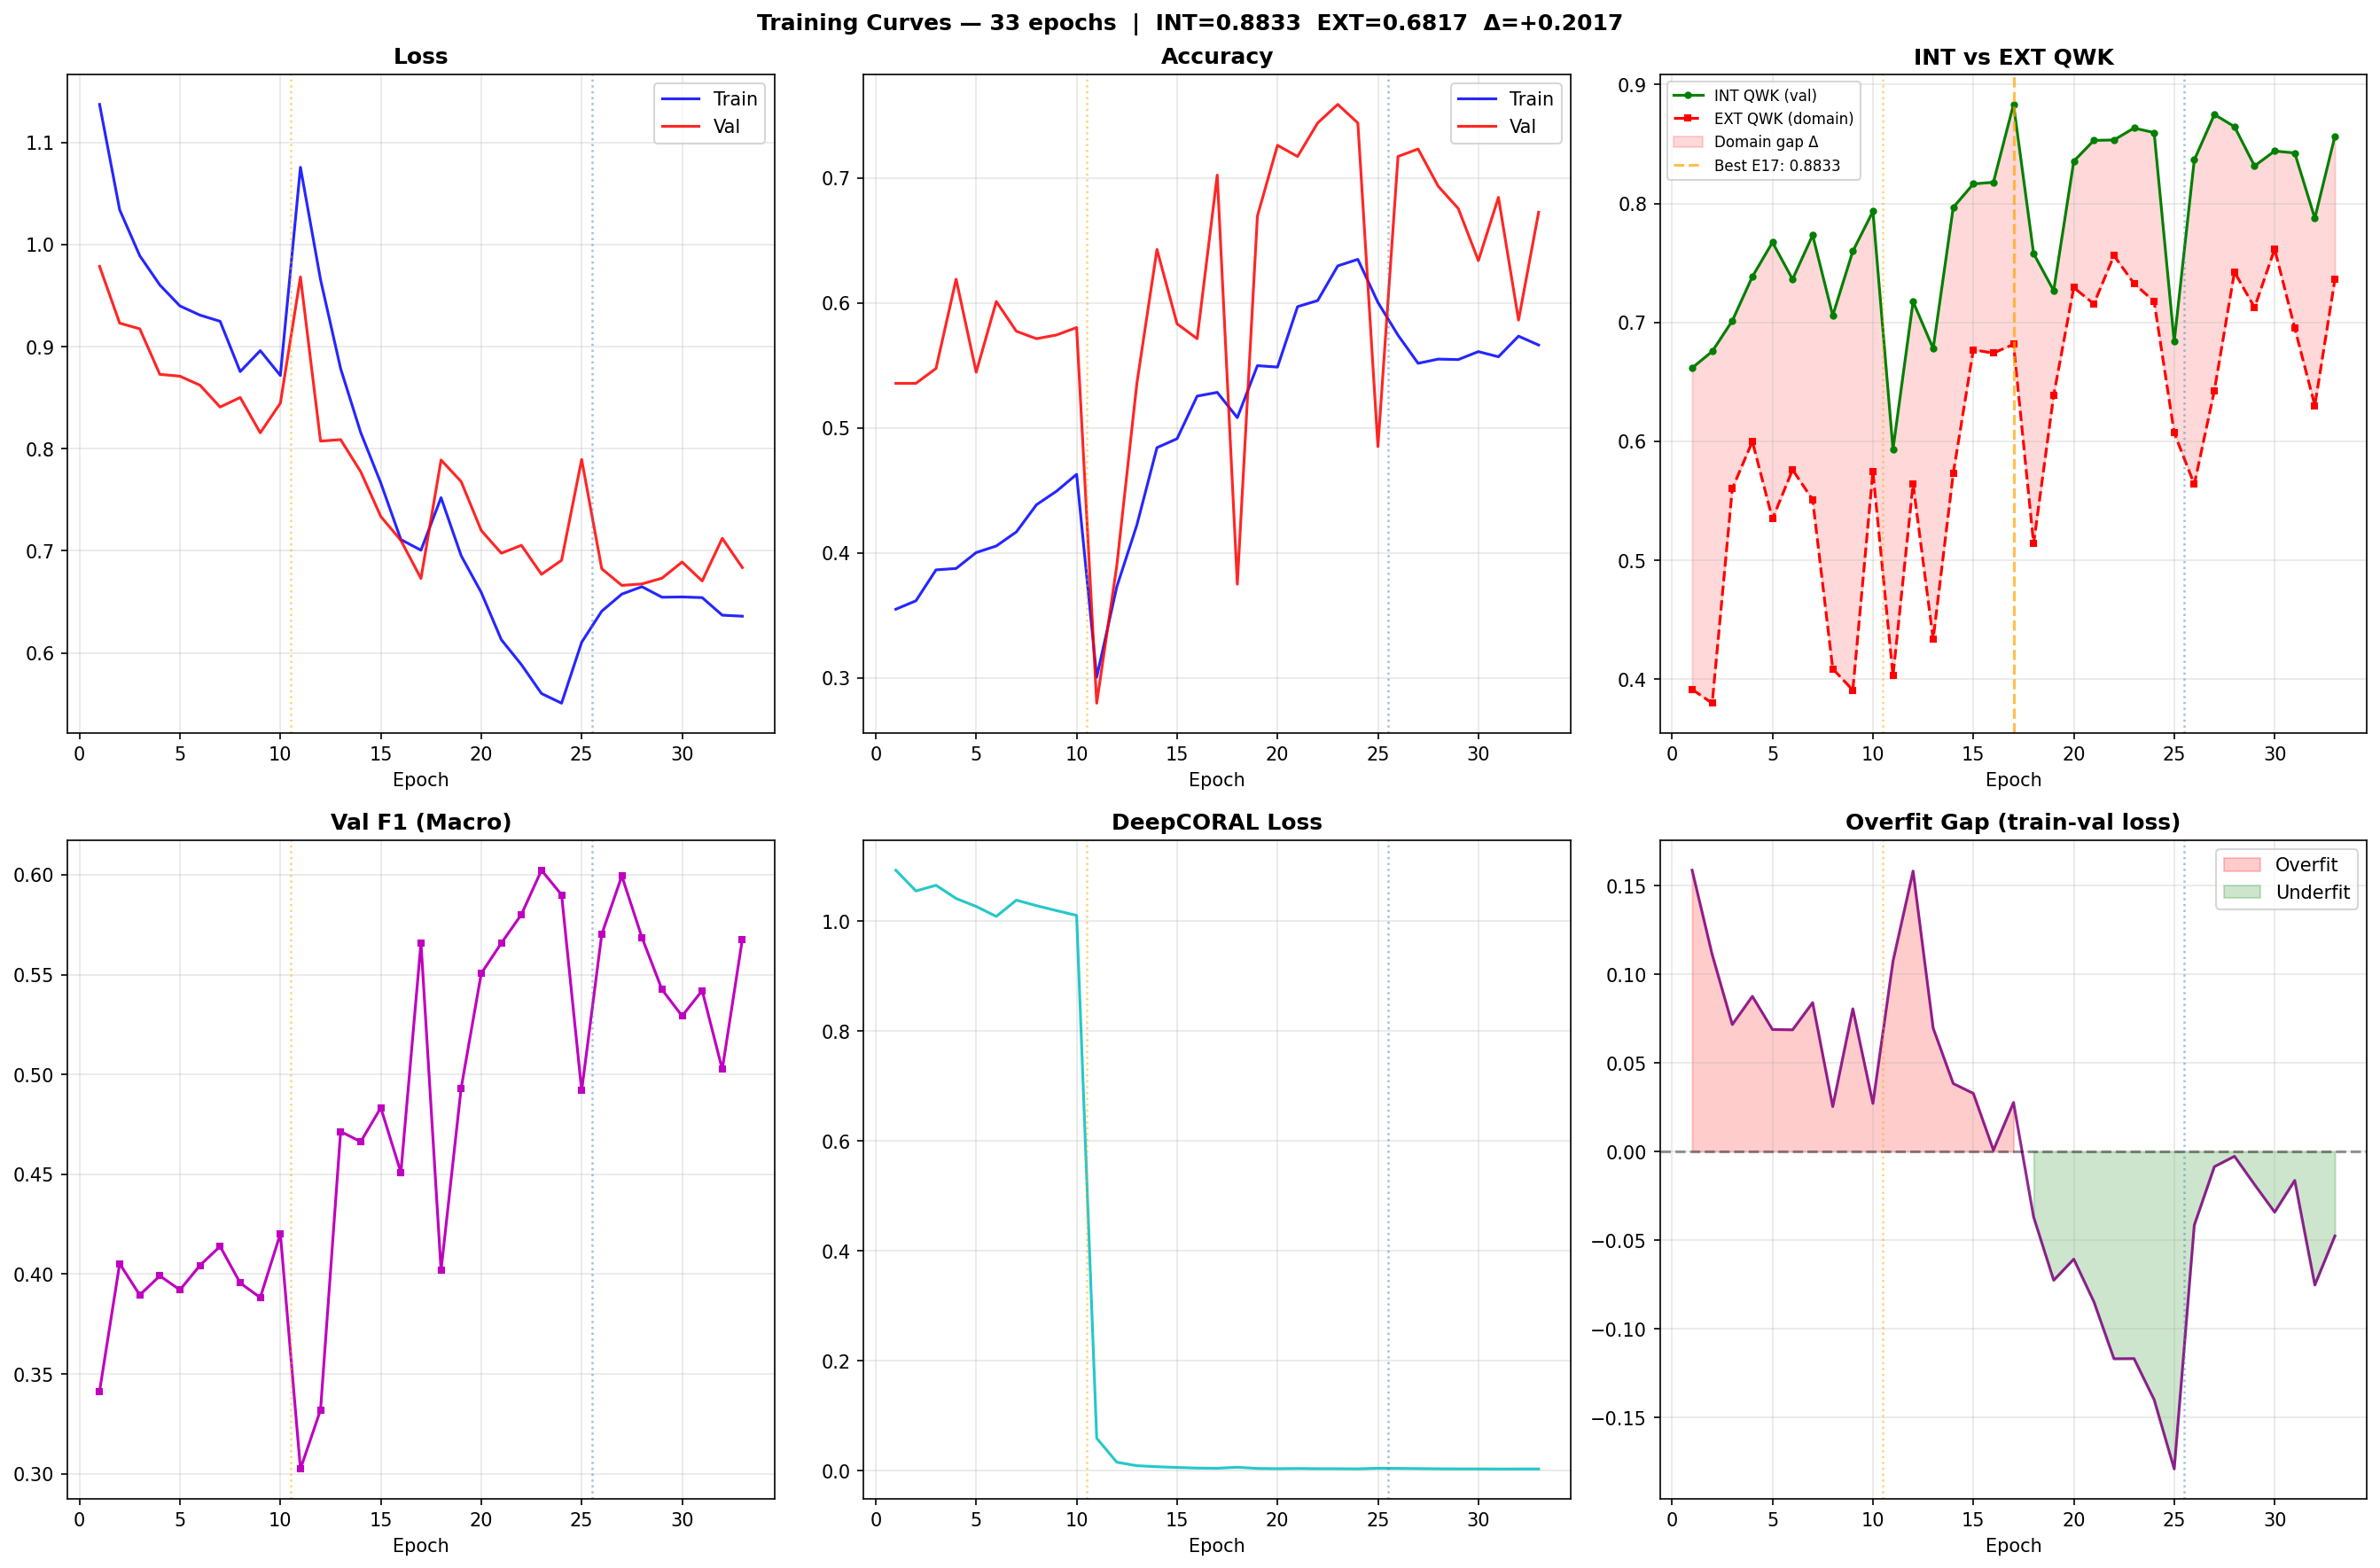


✅ Training curves — INT=0.8833  EXT=0.6817  Δ=+0.2017


In [23]:
# ═══════════════════════════════════════════════════════════════
#  Cell 17: TRAINING CURVES
#  ✅ FIX: matplotlib Agg → IPython.display.Image (always shows)
#  ✅ FIX: always regenerates regardless of _CS state
#  ✅ FIX: INT_QWK + EXT_QWK with domain gap fill + phase lines
# ═══════════════════════════════════════════════════════════════
from IPython.display import display as _ipy_disp, Image as _IPyImg

_FLAG = ARTIFACT_DIR / "training_curves.png"
_h    = history
_eps  = list(range(1, len(_h.get("train_loss", [])) + 1))

if not _eps:
    print("\u26a0\ufe0f  No training history — run Phases 1-3 first")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    axes[0,0].plot(_eps, _h["train_loss"], "b-", lw=1.5, label="Train", alpha=0.85)
    axes[0,0].plot(_eps, _h["val_loss"],   "r-", lw=1.5, label="Val",   alpha=0.85)
    axes[0,0].set_title("Loss", fontweight="bold")
    axes[0,0].legend(); axes[0,0].set_xlabel("Epoch"); axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(_eps, _h["train_acc"], "b-", lw=1.5, label="Train", alpha=0.85)
    axes[0,1].plot(_eps, _h["val_acc"],   "r-", lw=1.5, label="Val",   alpha=0.85)
    axes[0,1].set_title("Accuracy", fontweight="bold")
    axes[0,1].legend(); axes[0,1].set_xlabel("Epoch"); axes[0,1].grid(alpha=0.3)

    axes[0,2].plot(_eps, _h["val_qwk"], "g-o", ms=3, lw=1.5, label="INT QWK (val)")
    if _h.get("val_qwk_ext") and len(_h["val_qwk_ext"]) == len(_eps):
        axes[0,2].plot(_eps, _h["val_qwk_ext"], "r--s", ms=3, lw=1.5, label="EXT QWK (domain)")
        axes[0,2].fill_between(_eps, _h["val_qwk"], _h["val_qwk_ext"],
                               alpha=0.15, color="red", label="Domain gap \u0394")
    _be = int(np.argmax(_h["val_qwk"])) + 1
    _best_qwk_val = max(_h['val_qwk'])
    axes[0,2].axvline(_be, color="orange", ls="--", alpha=0.7, lw=1.5,
                       label=f"Best E{_be}: {_best_qwk_val:.4f}")
    axes[0,2].set_title("INT vs EXT QWK", fontweight="bold")
    axes[0,2].legend(fontsize=8); axes[0,2].set_xlabel("Epoch"); axes[0,2].grid(alpha=0.3)

    if _h.get("val_f1"):
        _fe = list(range(1, len(_h["val_f1"]) + 1))
        axes[1,0].plot(_fe, _h["val_f1"], "m-s", ms=3, lw=1.5)
        axes[1,0].set_title("Val F1 (Macro)", fontweight="bold")
        axes[1,0].set_xlabel("Epoch"); axes[1,0].grid(alpha=0.3)

    if _h.get("coral_loss"):
        _ce = list(range(1, len(_h["coral_loss"]) + 1))
        axes[1,1].plot(_ce, _h["coral_loss"], "c-", lw=1.5, alpha=0.85)
        axes[1,1].set_title("DeepCORAL Loss", fontweight="bold")
        axes[1,1].set_xlabel("Epoch"); axes[1,1].grid(alpha=0.3)

    _gap = [t - v for t, v in zip(_h["train_loss"], _h["val_loss"])]
    axes[1,2].plot(_eps, _gap, color="purple", lw=1.5, alpha=0.85)
    axes[1,2].axhline(0, color="k", ls="--", alpha=0.4)
    axes[1,2].fill_between(_eps, _gap, 0, where=[g > 0 for g in _gap],
                           color="red",   alpha=0.2, label="Overfit")
    axes[1,2].fill_between(_eps, _gap, 0, where=[g <= 0 for g in _gap],
                           color="green", alpha=0.2, label="Underfit")
    axes[1,2].set_title("Overfit Gap (train-val loss)", fontweight="bold")
    axes[1,2].legend(); axes[1,2].set_xlabel("Epoch"); axes[1,2].grid(alpha=0.3)

    for ax in axes.flatten():
        for pep, col in [(EPOCHS_HEAD, "orange"), (EPOCHS_HEAD + EPOCHS_FULL, "steelblue")]:
            if 0 < pep < len(_eps):
                ax.axvline(pep + 0.5, color=col, ls=":", alpha=0.5, lw=1.2)

    _best_int = max(_h["val_qwk"])
    _best_ext = _h["val_qwk_ext"][int(np.argmax(_h["val_qwk"]))] if _h.get("val_qwk_ext") else 0.
    _dg = _best_int - _best_ext
    plt.suptitle(
        f"Training Curves — {len(_eps)} epochs  |  "
        f"INT={_best_int:.4f}  EXT={_best_ext:.4f}  \u0394={_dg:+.4f}",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(_FLAG, dpi=150, bbox_inches="tight")
    plt.close(fig)

    # ✅ FIX: Agg backend — must use IPython display, not plt.show()
    _ipy_disp(_IPyImg(filename=str(_FLAG)))
    print(f"\n\u2705 Training curves — INT={_best_int:.4f}  EXT={_best_ext:.4f}  \u0394={_dg:+.4f}")
    _st_save("step17_curves", True)


✅ [RESUME] Predictions loaded
   Val  QWK: 0.8748
   Test QWK: 0.8250

  EVALUATION RESULTS

  Validation:
    QWK            : 0.8748  ← target ≥ 0.80
    Accuracy       : 72.46%
    F1 macro       : 0.5994
    F1 weighted    : 0.7356
    AUROC macro    : 0.9164
    Binary AUROC   : 0.9381
    Sensitivity    : 0.8852
    Specificity    : 0.9245

  Test:
    QWK            : 0.8250  ← target ≥ 0.80
    Accuracy       : 73.65%
    F1 macro       : 0.6100
    F1 weighted    : 0.7515
    AUROC macro    : 0.8929
    Binary AUROC   : 0.9475
    Sensitivity    : 0.9262
    Specificity    : 0.9057


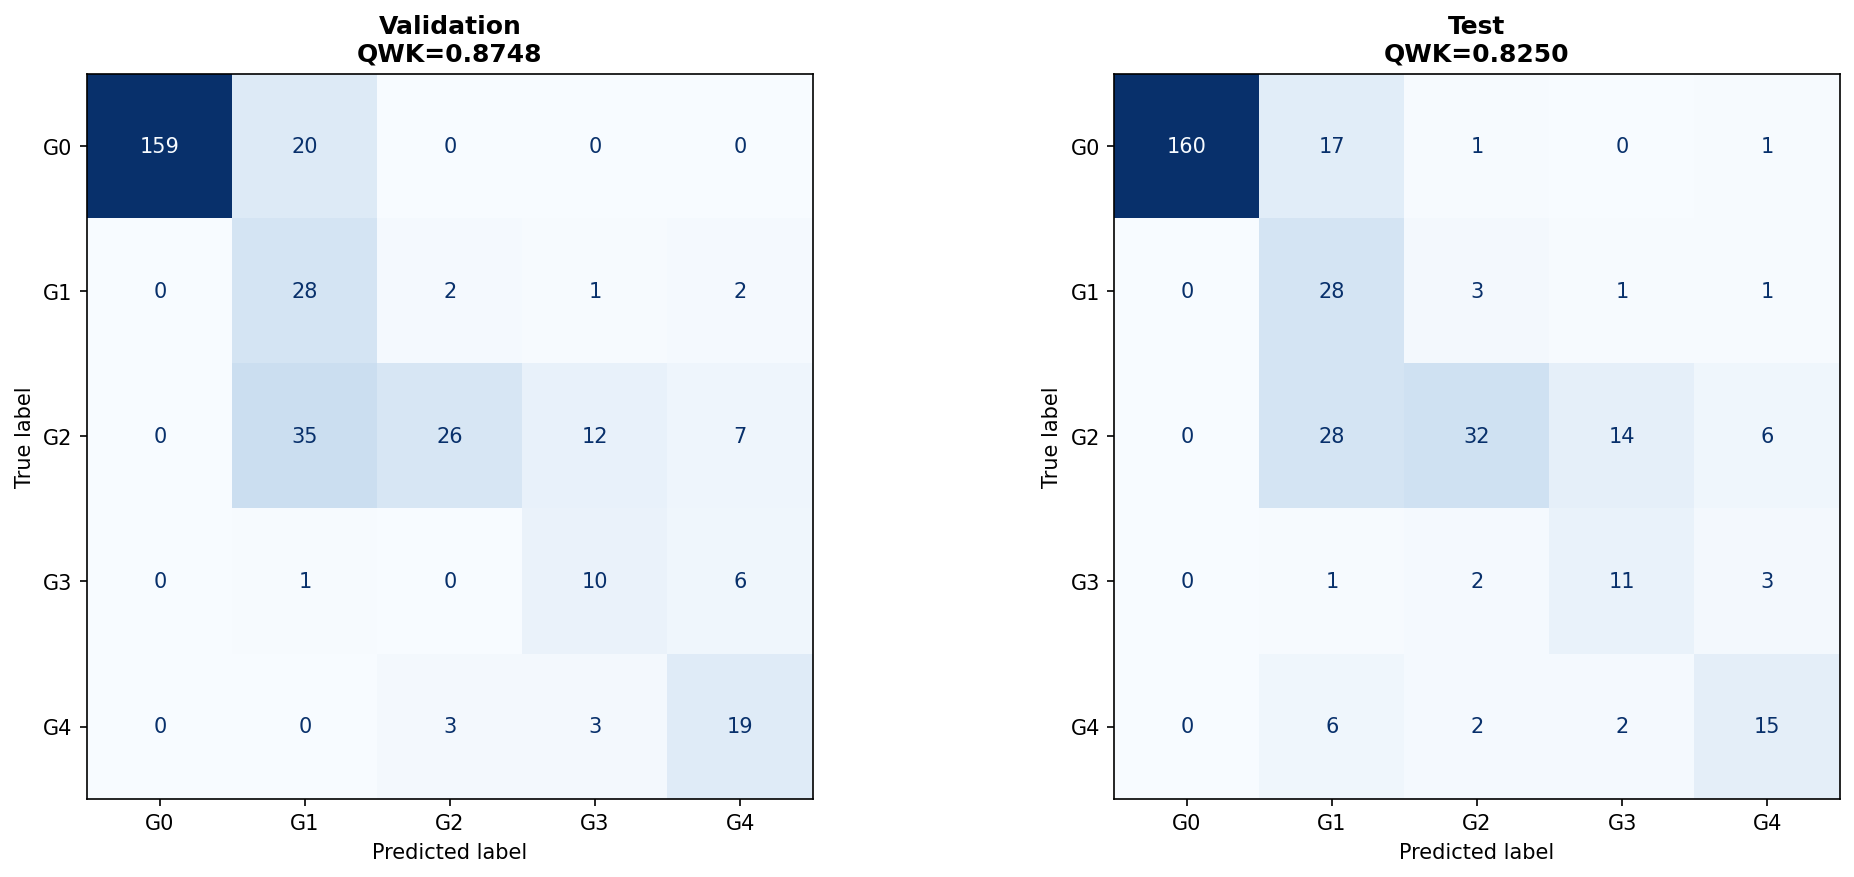


  Confusion matrices shown above

  Test classification report:
                     precision    recall  f1-score   support

           G0:No DR       1.00      0.89      0.94       179
         G1:Mild DR       0.35      0.85      0.50        33
     G2:Moderate DR       0.80      0.40      0.53        80
       G3:Severe DR       0.39      0.65      0.49        17
G4:Proliferative DR       0.58      0.60      0.59        25

           accuracy                           0.74       334
          macro avg       0.62      0.68      0.61       334
       weighted avg       0.83      0.74      0.75       334



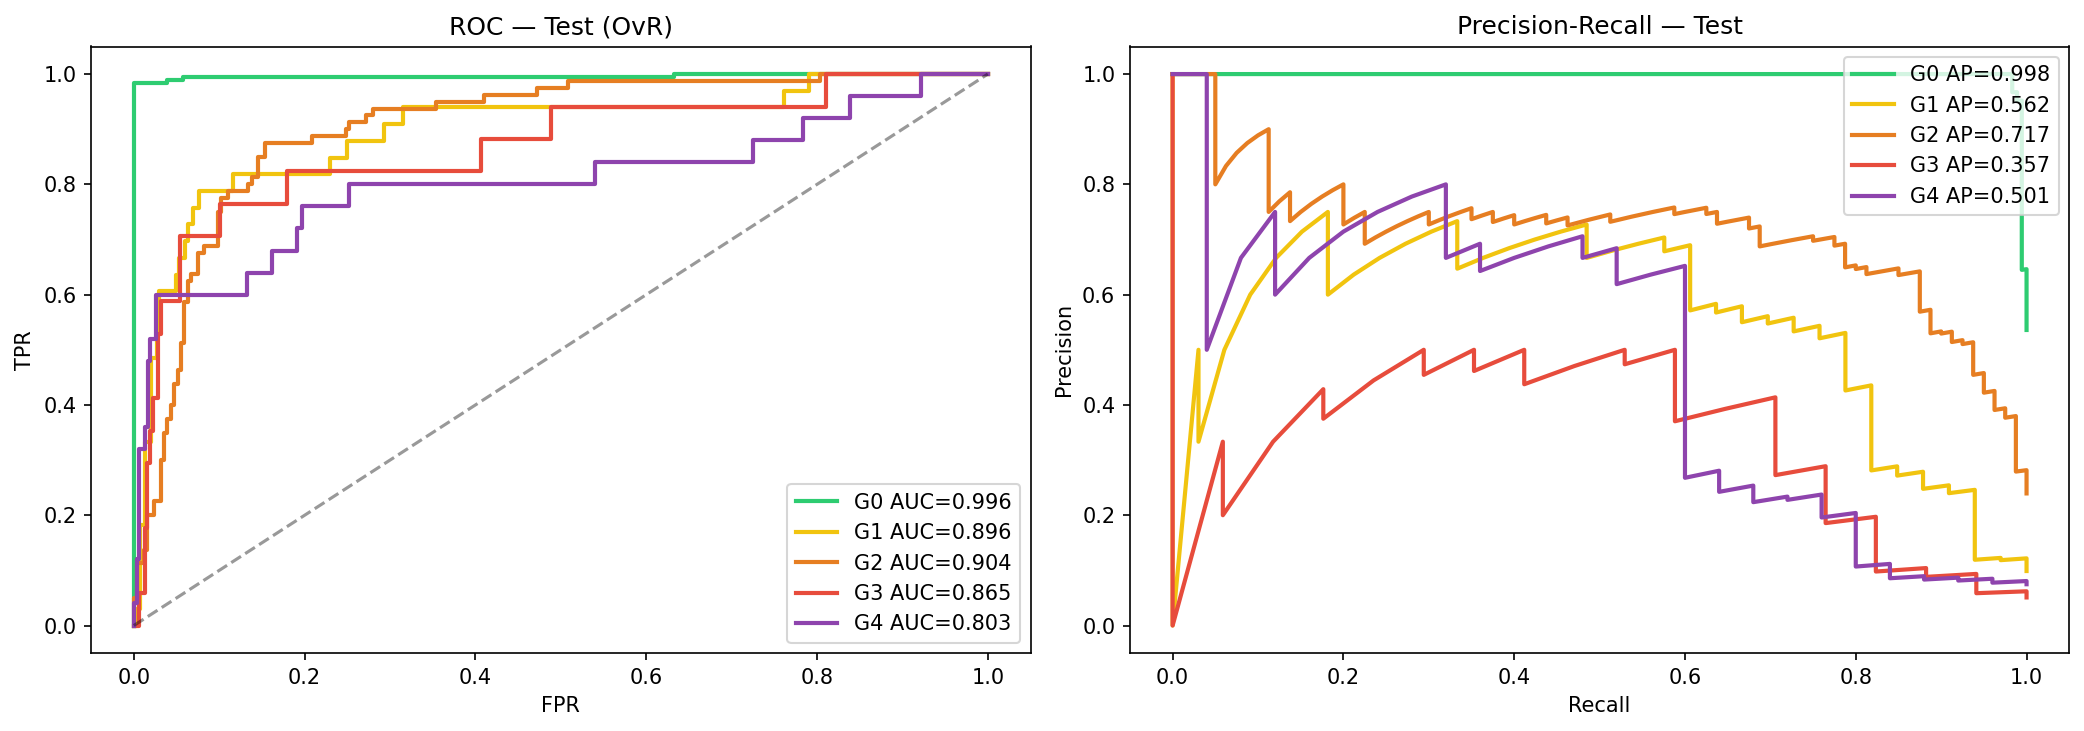

  ROC/PR curves shown above


In [24]:
# ═══════════════════════════════════════════════════════════════
#  Cell 18: FULL EVALUATION
#  QWK · Accuracy · F1 · AUROC · Confusion Matrix · ROC/PR
#  ✅ FIX: IPython.display.Image for all plots (Agg backend)
#  ✅ FIX: metrics table always printed first
# ═══════════════════════════════════════════════════════════════
from IPython.display import display as _ipy_disp, Image as _IPyImg
from sklearn.metrics import roc_curve, roc_auc_score, recall_score
from sklearn.metrics import precision_recall_curve, average_precision_score

_CS = _CellState("step18_eval")
_PNPZ = ARTIFACT_DIR / "predictions.npz"
_MCSV = ARTIFACT_DIR / "metrics_summary.csv"
BEST_CKPT = ARTIFACT_DIR / "best_model.pt"

if _CS.done and _PNPZ.exists() and _MCSV.exists():
    _pc = np.load(str(_PNPZ))
    va_probs, va_preds, va_labels = _pc["va_probs"], _pc["va_preds"], _pc["va_labels"]
    te_probs, te_preds, te_labels = _pc["te_probs"], _pc["te_preds"], _pc["te_labels"]
    _dm = pd.read_csv(_MCSV)
    val_metrics  = _dm[_dm["split"]=="Validation"].iloc[0].to_dict()
    test_metrics = _dm[_dm["split"]=="Test"].iloc[0].to_dict()
    print(f"\u2705 [RESUME] Predictions loaded")
    print(f"   Val  QWK: {qwk_score(va_labels, va_preds):.4f}")
    print(f"   Test QWK: {qwk_score(te_labels, te_preds):.4f}")
else:
    if BEST_CKPT.exists():
        _d = load_checkpoint(BEST_CKPT, model)
        _ld_qwk = _d.get('val_qwk', -1)
        print(f"  Loaded best model (INT_QWK={_ld_qwk:.4f})")

    def _full_eval(loader, sname):
        model.eval()
        all_probs, all_preds, all_labels = [], [], []
        with torch.no_grad():
            for imgs, labels in tqdm(loader, desc=f"  Eval-{sname}", leave=False):
                imgs = imgs.to(DEVICE, non_blocking=False)
                with _AMP_CTX:
                    logits, _ = model(imgs)
                prbs = torch.softmax(logits, dim=1).cpu().numpy()
                all_probs.append(prbs)
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.numpy())
        return np.vstack(all_probs), np.array(all_preds), np.array(all_labels)

    va_probs, va_preds, va_labels = _full_eval(val_loader,  "Val")
    te_probs, te_preds, te_labels = _full_eval(test_loader, "Test")
    np.savez_compressed(str(_PNPZ),
        va_probs=va_probs, va_preds=va_preds, va_labels=va_labels,
        te_probs=te_probs, te_preds=te_preds, te_labels=te_labels)

    def _metrics(labels, preds, probs, split):
        qwk  = qwk_score(labels, preds)
        acc  = float((labels==preds).mean())
        f1_m = float(f1_score(labels, preds, average="macro",    zero_division=0))
        f1_w = float(f1_score(labels, preds, average="weighted", zero_division=0))
        f1pc = f1_score(labels, preds, average=None, zero_division=0)
        bt   = (labels >= 2).astype(int); bs = probs[:,2:].sum(1)
        try:
            fpr,tpr,thr = roc_curve(bt, bs); bthr = float(thr[np.argmax(tpr-fpr)])
        except: bthr = 0.5
        bp   = (bs >= bthr).astype(int)
        tn   = int(((bt==0)&(bp==0)).sum()); fp = int(((bt==0)&(bp==1)).sum())
        sens = float(recall_score(bt, bp, zero_division=0))
        spec = tn / (tn + fp + 1e-8)
        try:
            _tb  = label_binarize(labels, classes=list(range(5)))
            auroc    = float(roc_auc_score(_tb, probs, multi_class="ovr", average="macro"))
            bin_auroc= float(roc_auc_score(bt, bs))
        except: auroc = bin_auroc = 0.0
        return {"split":split,"qwk":qwk,"acc":acc,"f1_macro":f1_m,"f1_weighted":f1_w,
                "auroc_macro":auroc,"bin_auroc":bin_auroc,"sensitivity":sens,"specificity":spec,
                **{f"f1_grade{i}": float(f1pc[i]) if i < len(f1pc) else 0. for i in range(5)}}

    val_metrics  = _metrics(va_labels, va_preds, va_probs, "Validation")
    test_metrics = _metrics(te_labels, te_preds, te_probs, "Test")
    pd.DataFrame([val_metrics, test_metrics]).to_csv(_MCSV, index=False)
    _CS.finish(True)

# ── Metrics table (always printed) ────────────────────────────────────────────
_sep62 = "=" * 62
print(f"\n{_sep62}")
print("  EVALUATION RESULTS")
print(f"{_sep62}")
for split, m in [("Validation", val_metrics), ("Test", test_metrics)]:
    print(f"\n  {split}:")
    # extract metric values to avoid backslash/quote conflicts in f-strings
    _mq   = m['qwk'];          _ma = m['acc'];       _mf1  = m['f1_macro']
    _mf1w = m['f1_weighted'];  _mr = m['auroc_macro']; _mb  = m['bin_auroc']
    _mse  = m['sensitivity'];  _msp = m['specificity']
    print(f"    QWK            : {_mq:.4f}  ← target ≥ 0.80")
    print(f"    Accuracy       : {_ma*100:.2f}%")
    print(f"    F1 macro       : {_mf1:.4f}")
    print(f"    F1 weighted    : {_mf1w:.4f}")
    print(f"    AUROC macro    : {_mr:.4f}")
    print(f"    Binary AUROC   : {_mb:.4f}")
    print(f"    Sensitivity    : {_mse:.4f}")
    print(f"    Specificity    : {_msp:.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
_cm_path = ARTIFACT_DIR / "confusion_matrix.png"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (nm, lbl, pred) in zip(axes, [
    ("Validation", va_labels, va_preds), ("Test", te_labels, te_preds)
]):
    ConfusionMatrixDisplay(confusion_matrix(lbl, pred),
        display_labels=[f"G{i}" for i in range(5)]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{nm}\nQWK={qwk_score(lbl,pred):.4f}", fontweight="bold")
plt.tight_layout()
plt.savefig(_cm_path, dpi=150, bbox_inches="tight"); plt.close(fig)
_ipy_disp(_IPyImg(filename=str(_cm_path)))   # ✅ Agg-safe
print("\n  Confusion matrices shown above")

# ── Per-class report ──────────────────────────────────────────────────────────
print("\n  Test classification report:")
print(classification_report(te_labels, te_preds,
      target_names=[f"G{i}:{GRADE_MAP[i]}" for i in range(5)]))

# ── ROC + PR curves ───────────────────────────────────────────────────────────
_roc_path = ARTIFACT_DIR / "roc_pr_curves.png"
_tb = label_binarize(te_labels, classes=list(range(5)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(GRADE_COLORS):
    try:
        fpr,tpr,_ = roc_curve(_tb[:,i], te_probs[:,i])
        auc = roc_auc_score(_tb[:,i], te_probs[:,i])
        axes[0].plot(fpr, tpr, color=col, lw=2, label=f"G{i} AUC={auc:.3f}")
    except: pass
axes[0].plot([0,1],[0,1],"k--",alpha=0.4)
axes[0].set_title("ROC — Test (OvR)"); axes[0].legend(loc="lower right")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
for i, col in enumerate(GRADE_COLORS):
    try:
        prec,rec,_ = precision_recall_curve(_tb[:,i], te_probs[:,i])
        ap = average_precision_score(_tb[:,i], te_probs[:,i])
        axes[1].plot(rec, prec, color=col, lw=2, label=f"G{i} AP={ap:.3f}")
    except: pass
axes[1].set_title("Precision-Recall — Test"); axes[1].legend(loc="upper right")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
plt.tight_layout()
plt.savefig(_roc_path, dpi=150, bbox_inches="tight"); plt.close(fig)
_ipy_disp(_IPyImg(filename=str(_roc_path)))  # ✅ Agg-safe
print("  ROC/PR curves shown above")


  Loaded best model (INT_QWK=0.8748)

🔁 TTA (5 passes): clean + hflip + vflip + brightness + rot90


  TTA-Val 1/5:   0%|          | 0/84 [00:00<?, ?it/s]

  TTA-Val 2/5:   0%|          | 0/84 [00:00<?, ?it/s]

  TTA-Val 3/5:   0%|          | 0/84 [00:00<?, ?it/s]

  TTA-Val 4/5:   0%|          | 0/84 [00:00<?, ?it/s]

...

  TTA-Test 3/5:   0%|          | 0/84 [00:00<?, ?it/s]

  TTA-Test 4/5:   0%|          | 0/84 [00:00<?, ?it/s]

  TTA-Test 5/5:   0%|          | 0/84 [00:00<?, ?it/s]

  TTA-ExtShift:   0%|          | 0/84 [00:00<?, ?it/s]


  TTA RESULTS (5 passes)
  Metric                         Single      TTA     Gain
  --------------------------------------------------------
  Val  INT_QWK                   0.8748   0.8666  -0.0082
  Test INT_QWK                   0.8250   0.8269  +0.0019
  Test EXT_QWK (domain)         {tta_ext_qwk:>8.4f}
  TTA Domain gap Δ              +0.1368  🔴 POOR


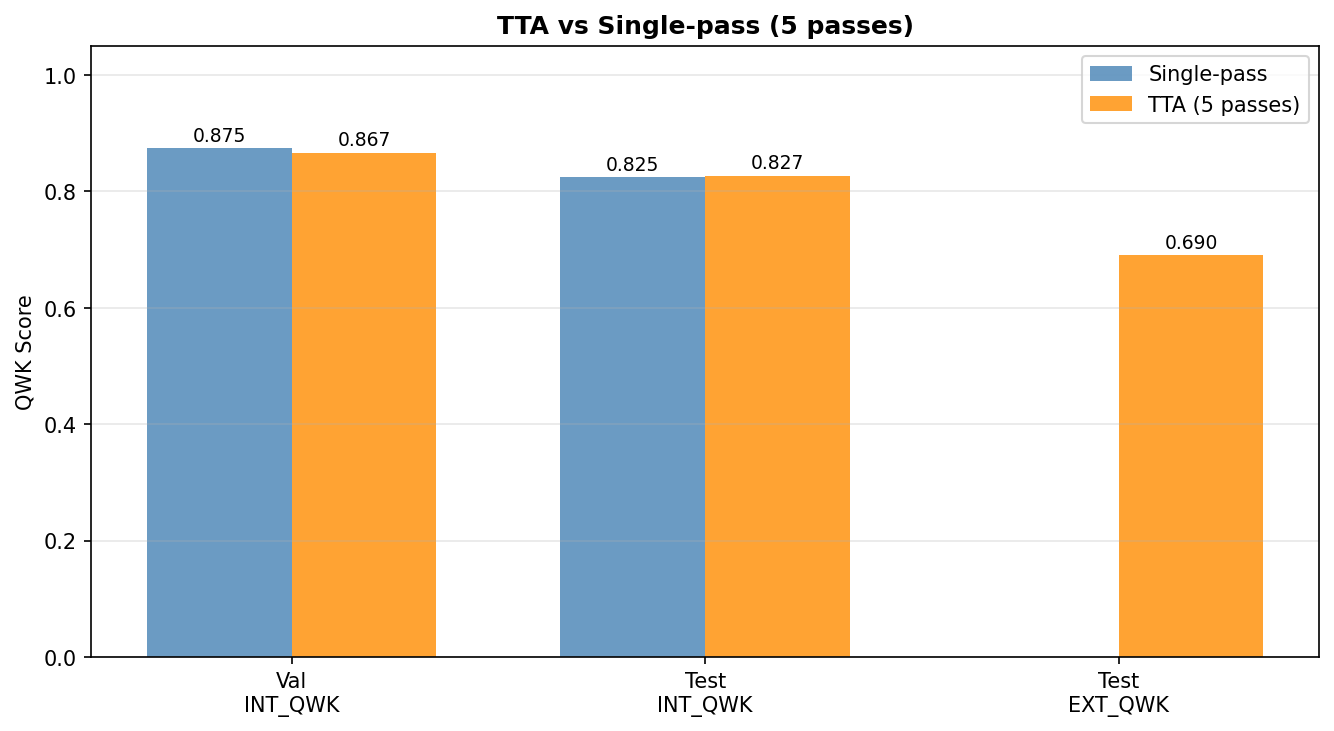


  TTA chart shown above


In [25]:
# ═══════════════════════════════════════════════════════════════
#  Cell 18b: TTA EVALUATION (Test-Time Augmentation)
#  ✅ FIX: DRDataset uses tfms= (was transforms= → TypeError)
#  ✅ FIX: IPython.display for inline chart (Agg backend)
#  Expected: +0.03–0.08 EXT_QWK gain
# ═══════════════════════════════════════════════════════════════
from IPython.display import display as _ipy_disp, Image as _IPyImg

_TTA_N = 5

_tta_tfms = [
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE),
               A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2()]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.HorizontalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2()]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.VerticalFlip(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2()]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE),
               A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=1.0),
               A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2()]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.RandomRotate90(p=1.0),
               A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2()]),
]

def _tta_loader_predict(df_split, cache_dir, batch_size=None, desc="TTA"):
    """
    Average probabilities across all TTA passes.
    ✅ FIX: uses tfms= kwarg to match DRDataset.__init__
    """
    bs = batch_size or BATCH_SIZE
    sum_probs = None; all_labels = None
    for vi, tfm in enumerate(_tta_tfms):
        # ✅ FIX: tfms= (original code had transforms= which crashed)
        ds  = DRDataset(df_split, tfms=tfm, cache_dir=cache_dir)
        ldr = DataLoader(ds, batch_size=bs, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        vp, vl = [], []
        model.eval()
        with torch.no_grad():
            for imgs, labels in tqdm(ldr, desc=f"  {desc} {vi+1}/{_TTA_N}", leave=False):
                imgs = imgs.to(DEVICE, non_blocking=False)
                with _AMP_CTX:
                    logits, _ = model(imgs)
                vp.append(torch.softmax(logits, dim=1).cpu().numpy())
                if vi == 0: vl.extend(labels.numpy())
        vp = np.vstack(vp)
        if sum_probs is None:
            sum_probs = vp.copy(); all_labels = np.array(vl)
        else:
            sum_probs += vp
    avg = sum_probs / len(_tta_tfms)
    return avg, avg.argmax(1), all_labels

BEST_CKPT = ARTIFACT_DIR / "best_model.pt"
if BEST_CKPT.exists():
    _d = load_checkpoint(BEST_CKPT, model)
    _ld_qwk = _d.get('val_qwk', -1)
    print(f"  Loaded best model (INT_QWK={_ld_qwk:.4f})")

print(f"\n\U0001f501 TTA ({_TTA_N} passes): clean + hflip + vflip + brightness + rot90")

tta_va_probs, tta_va_preds, tta_va_labels = _tta_loader_predict(df_va, _CACHE_DIR, desc="TTA-Val")
tta_te_probs, tta_te_preds, tta_te_labels = _tta_loader_predict(df_te, _CACHE_DIR, desc="TTA-Test")

# domain-shifted TTA (single pass, shift transform)
_ds_ds2 = DRDataset(df_te, tfms=domain_shift_transforms, cache_dir=_CACHE_DIR)
_ds_ldr = DataLoader(_ds_ds2, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
_dsp, _dsl = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in tqdm(_ds_ldr, desc="  TTA-ExtShift", leave=False):
        imgs = imgs.to(DEVICE, non_blocking=False)
        with _AMP_CTX: logits, _ = model(imgs)
        _dsp.append(torch.softmax(logits, dim=1).cpu().numpy())
        _dsl.extend(labels.numpy())
tta_ext_preds  = np.vstack(_dsp).argmax(1)
tta_ext_labels = np.array(_dsl)

tta_val_qwk  = qwk_score(tta_va_labels,  tta_va_preds)
tta_test_qwk = qwk_score(tta_te_labels,  tta_te_preds)
tta_ext_qwk  = qwk_score(tta_ext_labels, tta_ext_preds)
_sv = qwk_score(va_labels, va_preds)  if "va_labels" in dir() else 0.
_st = qwk_score(te_labels, te_preds)  if "te_labels" in dir() else 0.

_sep62 = "=" * 62
print(f"\n{_sep62}")
print(f"  TTA RESULTS ({_TTA_N} passes)")
print(f"{_sep62}")
print(f"  {'Metric':<28} {'Single':>8} {'TTA':>8} {'Gain':>8}")
print("  " + "-"*56)
print(f"  {'Val  INT_QWK':<28} {_sv:>8.4f} {tta_val_qwk:>8.4f} {tta_val_qwk-_sv:>+8.4f}")
print(f"  {'Test INT_QWK':<28} {_st:>8.4f} {tta_test_qwk:>8.4f} {tta_test_qwk-_st:>+8.4f}")
print(f"  {'Test EXT_QWK (domain)':<28} "        " {tta_ext_qwk:>8.4f}")
_dom = tta_test_qwk - tta_ext_qwk
_st2 = "\U0001f7e2 GOOD" if _dom<0.05 else ("\U0001f7e1 MOD" if _dom<0.10 else "\U0001f534 POOR")
_lbl = "TTA Domain gap Δ"
print(f"  {_lbl:<28} {_dom:>+8.4f}  {_st2}")
print(f"{_sep62}")

_tta_path = ARTIFACT_DIR / "tta_comparison.png"
fig, ax = plt.subplots(figsize=(9, 5))
_x = np.arange(3); _w = 0.35
_sp_ = [_sv, _st, 0]; _ta_ = [tta_val_qwk, tta_test_qwk, tta_ext_qwk]
_lb  = ["Val\nINT_QWK", "Test\nINT_QWK", "Test\nEXT_QWK"]
b1 = ax.bar(_x-_w/2, _sp_, _w, label="Single-pass", color="steelblue", alpha=0.8)
b2 = ax.bar(_x+_w/2, _ta_, _w, label=f"TTA ({_TTA_N} passes)", color="darkorange", alpha=0.8)
for rect in list(b1)+list(b2):
    h = rect.get_height()
    if h > 0: ax.text(rect.get_x()+rect.get_width()/2, h+0.005, f"{h:.3f}",
                      ha="center", va="bottom", fontsize=9)
ax.set_xticks(_x); ax.set_xticklabels(_lb)
ax.set_ylabel("QWK Score"); ax.set_ylim(0, 1.05)
ax.set_title(f"TTA vs Single-pass ({_TTA_N} passes)", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(_tta_path, dpi=150, bbox_inches="tight"); plt.close(fig)
_ipy_disp(_IPyImg(filename=str(_tta_path)))  # ✅ Agg-safe
print("\n  TTA chart shown above")


In [26]:
# ═══════════════════════════════════════════════════════════════
#  Cell 19: TEMPERATURE SCALING CALIBRATION
#  Post-hoc calibration to fix model over/under-confidence.
#  Outputs: ECE (Expected Calibration Error) + reliability diagram
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step19_calibration")
_CAL_FLAG = ARTIFACT_DIR / "calibration_plot.png"

class TemperatureScaler(nn.Module):
    """
    Post-hoc temperature scaling (Guo et al. 2017).
    Fits a single scalar T on the validation set NLL.
    T > 1 → softens predictions (reduce overconfidence)
    T < 1 → sharpens predictions (reduce underconfidence)
    """
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature.clamp(min=0.05, max=20.0)

    def calibrate(self, logits_tensor, labels_tensor):
        """LBFGS optimisation of NLL on validation logits."""
        self.train()
        opt = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=100)
        nll = nn.CrossEntropyLoss()

        def _step():
            opt.zero_grad()
            loss = nll(self.forward(logits_tensor), labels_tensor)
            loss.backward()
            return loss

        opt.step(_step)
        self.eval()
        return self.temperature.item()

def _expected_calibration_error(probs, labels, n_bins=15):
    """Compute ECE (Expected Calibration Error)."""
    conf  = probs.max(axis=1)
    pred  = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    bins  = np.linspace(0, 1, n_bins + 1)
    ece   = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf >= lo) & (conf < hi)
        if mask.sum() > 0:
            acc_bin = correct[mask].mean()
            conf_bin= conf[mask].mean()
            ece    += (mask.sum() / len(labels)) * abs(acc_bin - conf_bin)
    return ece

if _CS.done and _CAL_FLAG.exists():
    print("✅ [RESUME] Calibration already done — displaying:")
    _CellState.show_image("calibration_plot.png", figsize=(14, 5))
else:
    # Collect raw logits on val set
    BEST_CKPT = ARTIFACT_DIR / "best_model.pt"
    if BEST_CKPT.exists():
        load_checkpoint(BEST_CKPT, model)
    model.eval()

    _all_logits, _all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="  Collecting logits", leave=False):
            imgs = imgs.to(DEVICE, non_blocking=False)
            with _AMP_CTX:
                logits, _ = model(imgs)
            _all_logits.append(logits.cpu())
            _all_labels.extend(labels.numpy())

    _logits_t = torch.cat(_all_logits)         # (N, 5)
    _labels_t = torch.tensor(_all_labels, dtype=torch.long)
    _probs_raw= torch.softmax(_logits_t, dim=1).numpy()

    # Calibrate
    ts = TemperatureScaler()
    T  = ts.calibrate(_logits_t, _labels_t)
    _probs_cal = torch.softmax(ts(_logits_t), dim=1).detach().numpy()

    ece_before = _expected_calibration_error(_probs_raw,  np.array(_all_labels))
    ece_after  = _expected_calibration_error(_probs_cal,  np.array(_all_labels))

    print(f"  Temperature: {T:.3f}")
    print(f"  ECE before : {ece_before:.4f}")
    print(f"  ECE after  : {ece_after:.4f}")
    if T > 1.0:
        print(f"  Interpretation: Model was OVERCONFIDENT (T={T:.3f}>1 softens outputs)")
    elif T < 1.0:
        print(f"  Interpretation: Model was UNDERCONFIDENT (T={T:.3f}<1 sharpens outputs)")
    else:
        print(f"  Interpretation: Model is well-calibrated (T≈1)")

    # ── Reliability diagram ────────────────────────────────────────────────────
    def _reliability_data(probs, labels, n_bins=15):
        conf    = probs.max(axis=1)
        pred    = probs.argmax(axis=1)
        correct = (pred == labels).astype(float)
        bins    = np.linspace(0, 1, n_bins + 1)
        bin_acc, bin_conf, bin_sizes = [], [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (conf >= lo) & (conf < hi)
            if mask.sum() > 0:
                bin_acc.append(correct[mask].mean())
                bin_conf.append(conf[mask].mean())
                bin_sizes.append(mask.sum())
            else:
                bin_acc.append(0.0); bin_conf.append((lo+hi)/2); bin_sizes.append(0)
        return np.array(bin_conf), np.array(bin_acc), np.array(bin_sizes)

    _labs = np.array(_all_labels)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, prbs, title, ece in [
        (axes[0], _probs_raw, f"Before Calibration (ECE={ece_before:.4f})", ece_before),
        (axes[1], _probs_cal, f"After Temperature Scaling (ECE={ece_after:.4f}, T={T:.3f})", ece_after),
    ]:
        bc, ba, bs = _reliability_data(prbs, _labs)
        ax.bar(bc, ba, width=1/15, alpha=0.7, color="steelblue",
               edgecolor="black", linewidth=0.5, label="Accuracy")
        ax.bar(bc, bc, width=1/15, alpha=0.25, color="red",
               edgecolor="none", label="Confidence (ideal)")
        ax.plot([0,1],[0,1],"r--", lw=1.5, label="Perfect calibration")
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
        ax.set_title(title, fontweight="bold")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(_CAL_FLAG, dpi=150, bbox_inches="tight")
    plt.savefig(_CAL_FLAG, dpi=150, bbox_inches="tight")
    plt.close(fig)
    from IPython.display import display as _ipy_disp2, Image as _IPyImg2
    _ipy_disp2(_IPyImg2(filename=str(_CAL_FLAG)))

    # Save temperature scaler
    torch.save({"temperature": T}, ARTIFACT_DIR/"temperature_scaler.pt")
    _st_save("temperature", T)
    print(f"\n✅ Calibration done — T={T:.4f}, ECE: {ece_before:.4f}→{ece_after:.4f}")
    _CS.finish(True)

✅ [RESUME] Calibration already done — displaying:


In [27]:
# ═══════════════════════════════════════════════════════════════
#  Cell 20: GRAD-CAM++ VISUALISATION
#  Medical-grade: TTA + retinal soft mask + gamma lift
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step20_gradcam")
_GCAM_FLAG = ARTIFACT_DIR / "gradcam_samples.png"

if not GRADCAM_AVAILABLE:
    print("⚠️  pytorch_grad_cam not installed")
    print("   Run: pip install pytorch-grad-cam")
elif _CS.done and _GCAM_FLAG.exists():
    print("✅ [RESUME] Grad-CAM++ already saved — displaying:")
    _CellState.show_image("gradcam_samples.png", figsize=(14, 22))
else:
    BEST_CKPT = ARTIFACT_DIR / "best_model.pt"
    if BEST_CKPT.exists():
        load_checkpoint(BEST_CKPT, model)
    model.eval()

    # ── Target layer: second-to-last block (sharper 16×16 maps) ──────────────
    def _get_target_layer(m):
        try: return [list(m.backbone.blocks[-2])[-1]]
        except: pass
        try: return [list(m.backbone.blocks[-1])[-1]]
        except: pass
        return [m.backbone.blocks[-1]]

    def _retinal_soft_mask(h, w, margin=0.04):
        cy, cx = h/2.0, w/2.0
        r = min(h,w) * (0.5 - margin)
        Y, X = np.mgrid[0:h, 0:w].astype(np.float32)
        d = np.sqrt((X-cx)**2 + (Y-cy)**2)
        return np.clip(1.0 - (d - r*0.85)/(r*0.15+1e-8), 0.0, 1.0)

    def _postprocess_cam(raw, h, w):
        cam  = cv2.resize(raw, (w, h)).astype(np.float32)
        lo, hi = np.percentile(cam, 2), np.percentile(cam, 98)
        cam  = np.clip((cam - lo)/(hi - lo + 1e-8), 0, 1)
        cam *= _retinal_soft_mask(h, w)
        k    = max(3, int(w*0.04)|1)
        cam  = cv2.GaussianBlur(cam, (k,k), 0)
        return np.power(np.clip(cam, 0, 1), 0.75).astype(np.float32)

    def _tta_cam(cam_obj, inp, pred_cls):
        tgt = [ClassifierOutputTarget(pred_cls)]
        try:
            c0  = cam_obj(input_tensor=inp, targets=tgt)[0]
            chf = cam_obj(input_tensor=torch.flip(inp,dims=[-1]), targets=tgt)[0]
            cvf = cam_obj(input_tensor=torch.flip(inp,dims=[-2]), targets=tgt)[0]
            return c0*0.50 + np.fliplr(chf)*0.35 + np.flipud(cvf)*0.15
        except Exception as e:
            print(f"⚠️ TTA CAM error: {e}")
            return cam_obj(input_tensor=inp, targets=tgt)[0]

    _inf_tfm = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

    _tgt_layer = _get_target_layer(model)
    _cam_obj   = GradCAMPlusPlus(model=model, target_layers=_tgt_layer)
    VIZ_SZ     = 224

    def _make_gradcam(img_path, true_label):
        raw = preprocess_fundus(img_path, target_size=IMG_SIZE, cache_dir=_CACHE_DIR)
        vis = cv2.resize(raw, (VIZ_SZ, VIZ_SZ))

        inp = _inf_tfm(image=raw)["image"].unsqueeze(0).to(DEVICE)
        model.eval()
        with torch.no_grad():
            logits, _ = model(inp)
            probs     = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred      = int(np.argmax(probs))
            conf      = float(probs[pred])

        raw_cam  = _tta_cam(_cam_obj, inp, true_label)
        proc_cam = _postprocess_cam(raw_cam, VIZ_SZ, VIZ_SZ)
        heat_rgb = cv2.cvtColor(
            cv2.applyColorMap((proc_cam*255).astype(np.uint8), cv2.COLORMAP_JET),
            cv2.COLOR_BGR2RGB)
        vis_f   = vis.astype(np.float32)/255.0
        overlay = cv2.addWeighted((vis_f*255).astype(np.uint8), 0.55, heat_rgb, 0.45, 0)
        return vis, overlay, pred, conf, probs

    fig, axes = plt.subplots(5, 3, figsize=(14, 22))
    fig.patch.set_facecolor("#0e1117")

    for gi in range(5):
        _samp = df_te[df_te["diagnosis"] == gi]
        if len(_samp) == 0:
            _samp = df_va[df_va["diagnosis"] == gi]
        if len(_samp) == 0:
            for ax in axes[gi]: ax.axis("off")
            continue
        row = _samp.iloc[0]
        try:
            orig, cam_ov, pred, conf, probs = _make_gradcam(row["image_path"], gi)
            axes[gi][0].imshow(orig)
            axes[gi][0].set_title("CLAHE Preprocessed", fontsize=9, color="white")
            axes[gi][1].imshow(cam_ov)
            axes[gi][1].set_title(f"Grad-CAM++ TTA (target G{gi})", fontsize=9, color="white")
            axes[gi][2].barh(
                [f"G{k} {GRADE_MAP[k][:9]}" for k in range(5)], probs, color=GRADE_COLORS)
            axes[gi][2].axvline(0.5, color="white", ls="--", alpha=0.3)
            axes[gi][2].set_xlim(0,1); axes[gi][2].set_facecolor("#1a1a2e")
            axes[gi][2].tick_params(colors="white", labelsize=8)
            axes[gi][2].set_title(
                f"Pred: G{pred} ({conf*100:.1f}%)", fontsize=9,
                color="#2ecc71" if pred==gi else "#e74c3c")
        except Exception as e:
            for ax in axes[gi]:
                ax.text(0.5,0.5,str(e)[:40],ha="center",transform=ax.transAxes,
                        color="red",fontsize=8)

        for ax in axes[gi][:2]:
            ax.axis("off"); ax.set_facecolor("black")
        axes[gi][0].set_ylabel(
            f"GT: G{gi}\n{GRADE_MAP[gi]}", fontsize=8, fontweight="bold",
            color=GRADE_COLORS[gi], rotation=0, labelpad=95, va="center")

    plt.suptitle(
        "Grad-CAM++ (TTA · Retinal Mask) — One Sample per Grade",
        fontsize=12, fontweight="bold", color="white", y=1.01)
    plt.tight_layout()
    plt.savefig(_GCAM_FLAG, dpi=150, bbox_inches="tight", facecolor="#0e1117")
    plt.show()
    print("✅ Grad-CAM++ visualisation saved")
    _CS.finish(True)

✅ [RESUME] Grad-CAM++ already saved — displaying:


In [28]:
# ═══════════════════════════════════════════════════════════════
#  Cell 21: DOMAIN SHIFT / EXTERNAL VALIDATION
#  Evaluates model under simulated domain shift:
#    • Colour jitter (different camera white balance)
#    • Gamma variation (different display/acquisition settings)
#    • Added noise (sensor noise simulation)
#  Reports QWK degradation as "domain gap".
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step21_domain_shift")
_DS_FLAG = ARTIFACT_DIR / "domain_shift_report.csv"

BEST_CKPT = ARTIFACT_DIR / "best_model.pt"
if BEST_CKPT.exists():
    load_checkpoint(BEST_CKPT, model)
model.eval()

print("🔬 Domain Shift Evaluation")
print("=" * 62)

def _eval_with_loader(loader, desc):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"  {desc}", leave=False):
            imgs = imgs.to(DEVICE, non_blocking=False)
            with _AMP_CTX:
                logits, _ = model(imgs)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    return {
        "qwk":      qwk_score(labels, preds),
        "acc":      float((labels==preds).mean()),
        "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "preds":    preds,
        "labels":   labels,
    }

# Clean test set (baseline)
res_clean = _eval_with_loader(test_loader,  "Clean Test")
# Domain-shifted test set (simulated cross-device)
res_shift = _eval_with_loader(ds_loader,    "Domain-Shifted Test")

print(f"\n  Clean Test QWK        : {res_clean['qwk']:.4f}")
print(f"  Domain-Shifted QWK    : {res_shift['qwk']:.4f}")
qwk_drop = res_clean["qwk"] - res_shift["qwk"]
print(f"  QWK Drop (domain gap) : {qwk_drop:.4f}")
if qwk_drop < 0.05:
    print("  Domain robustness: ✅ EXCELLENT (gap < 0.05)")
elif qwk_drop < 0.10:
    print("  Domain robustness: 🟡 GOOD (gap < 0.10)")
else:
    print("  Domain robustness: 🔴 POOR (gap ≥ 0.10 — consider stronger CORAL weight)")

print(f"\n  Clean  — Acc: {res_clean['acc']*100:.2f}%  F1: {res_clean['f1_macro']:.4f}")
print(f"  Shifted— Acc: {res_shift['acc']*100:.2f}%  F1: {res_shift['f1_macro']:.4f}")

# Per-grade robustness
print("\n  Per-grade QWK comparison:")
for gi in range(5):
    m_clean = (res_clean["labels"]==gi)
    m_shift = (res_shift["labels"]==gi)
    if m_clean.sum() == 0: continue
    # Per-class accuracy as proxy
    acc_c = float((res_clean["preds"][m_clean]==gi).mean())
    acc_s = float((res_shift["preds"][m_shift]==gi).mean()) if m_shift.sum()>0 else 0.0
    drop  = acc_c - acc_s
    flag  = "⚠️" if drop > 0.10 else "✅"
    print(f"  Grade {gi} ({GRADE_MAP[gi]:<25}): clean={acc_c:.3f}  shift={acc_s:.3f}  drop={drop:+.3f} {flag}")

pd.DataFrame([
    {"condition":"Clean", **{k:v for k,v in res_clean.items() if k not in ["preds","labels"]}},
    {"condition":"DomainShift", **{k:v for k,v in res_shift.items() if k not in ["preds","labels"]}},
]).to_csv(_DS_FLAG, index=False)
print(f"\n💾 Domain shift report → {_DS_FLAG.name}")

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nm, r) in zip(axes, [("Clean", res_clean), ("Domain-Shifted", res_shift)]):
    cm = confusion_matrix(r["labels"], r["preds"])
    ConfusionMatrixDisplay(cm, display_labels=[f"G{i}" for i in range(5)]).plot(
        ax=ax, cmap="Oranges", colorbar=False)
    ax.set_title(f"{nm}\nQWK={r['qwk']:.4f}", fontweight="bold")
plt.suptitle("Domain Shift: Clean vs Simulated Cross-Device", fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR/"domain_shift_cm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Domain shift confusion matrices saved")
_CS.finish(True)

🔬 Domain Shift Evaluation


  Clean Test:   0%|          | 0/84 [00:00<?, ?it/s]

  Domain-Shifted Test:   0%|          | 0/84 [00:00<?, ?it/s]


  Clean Test QWK        : 0.8250
  Domain-Shifted QWK    : 0.6948
  QWK Drop (domain gap) : 0.1302
  Domain robustness: 🔴 POOR (gap ≥ 0.10 — consider stronger CORAL weight)

  Clean  — Acc: 73.65%  F1: 0.6100
  Shifted— Acc: 64.37%  F1: 0.4893

  Per-grade QWK comparison:
  Grade 0 (No DR                    ): clean=0.894  shift=0.844  drop=+0.050 ✅
  Grade 1 (Mild DR                  ): clean=0.848  shift=0.848  drop=+0.000 ✅
  Grade 2 (Moderate DR              ): clean=0.400  shift=0.200  drop=+0.200 ⚠️
  Grade 3 (Severe DR                ): clean=0.647  shift=0.294  drop=+0.353 ⚠️
  Grade 4 (Proliferative DR         ): clean=0.600  shift=0.600  drop=+0.000 ✅

💾 Domain shift report → domain_shift_report.csv
✅ Domain shift confusion matrices saved


In [29]:
# ═══════════════════════════════════════════════════════════════
#  Cell 22: SAVE FINAL MODEL BUNDLE
#  Includes: weights, backbone, metrics, temperature, history
# ═══════════════════════════════════════════════════════════════
_CS = _CellState("step22_save")
FINAL_CKPT = ARTIFACT_DIR / "final_model.pt"
BEST_CKPT  = ARTIFACT_DIR / "best_model.pt"

if _CS.done and FINAL_CKPT.exists():
    sz = FINAL_CKPT.stat().st_size / 1e6
    print(f"✅ [RESUME] final_model.pt exists ({sz:.1f} MB)")
    ok, qwk, ep = validate_checkpoint(FINAL_CKPT)
    print(f"   Valid: {ok}  QWK: {qwk:.4f}  epoch: {ep}")
else:
    _d = _safe_load(BEST_CKPT, "cpu")
    model.load_state_dict(_d["model_state"])

    T = _st_get("temperature", 1.0)

    torch.save({
        "model_state":   model.state_dict(),
        "backbone":      BACKBONE,
        "num_classes":   NUM_CLASSES,
        "img_size":      IMG_SIZE,
        "grade_map":     GRADE_MAP,
        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std":  IMAGENET_STD,
        "val_metrics":   val_metrics,
        "test_metrics":  test_metrics,
        "history":       history,
        "temperature":   T,
        "seed":          SEED,
        "device_trained": DEVICE,
        "n_epochs":      len(history["train_loss"]),
        "val_qwk":       val_metrics["qwk"],
        "coral_weight":  CORAL_WEIGHT,
    }, FINAL_CKPT)

    sz = FINAL_CKPT.stat().st_size / 1e6
    print(f"✅ final_model.pt saved ({sz:.1f} MB)")
    print(f"   Backbone     : {BACKBONE}")
    print(f"   IMG_SIZE     : {IMG_SIZE}")
    print(f"   Val QWK      : {val_metrics['qwk']:.4f}")
    print(f"   Test QWK     : {test_metrics['qwk']:.4f}")
    print(f"   Temperature  : {T:.4f}")
    print(f"   DeepCORAL w  : {CORAL_WEIGHT}")
    _st_save("final_saved", True)
    _CS.finish(True)

✅ [RESUME] final_model.pt exists (89.0 MB)
   Valid: True  QWK: 0.8748  epoch: 0


In [30]:
# ═══════════════════════════════════════════════════════════════
#  Cell 23: FINAL SUMMARY + ARTIFACT INVENTORY
# ═══════════════════════════════════════════════════════════════
print("=" * 65)
print("  DIABETIC RETINOPATHY GRADING v9 — FINAL RESULTS")
print("=" * 65)

if "val_metrics" in dir() and "test_metrics" in dir():
    for split, m in [("Validation", val_metrics), ("Test", test_metrics)]:
        print(f"\n  {split}:")
        print(f"    QWK (primary)  : {m['qwk']:.4f}  ← target ≥ 0.80")
        print(f"    Accuracy       : {m['acc']*100:.2f}%")
        print(f"    F1 (macro)     : {m['f1_macro']:.4f}")
        print(f"    F1 (weighted)  : {m['f1_weighted']:.4f}")
        print(f"    AUROC (macro)  : {m['auroc_macro']:.4f}")
        print(f"    Binary AUROC   : {m['bin_auroc']:.4f}")
        print(f"    Sensitivity    : {m['sensitivity']:.4f}")
        print(f"    Specificity    : {m['specificity']:.4f}")
        f1s = "  ".join(f"G{i}:{m[f'f1_grade{i}']:.3f}" for i in range(5))
        print(f"    Per-class F1   : {f1s}")
else:
    print("  ⚠️  Metrics not available — run Cells 14–18 first")

print(f"\n  Training Summary:")
print(f"    Total epochs   : {len(history.get('train_loss',[]))}")
if history.get("val_qwk"):
    print(f"    Best Val QWK   : {max(history['val_qwk']):.4f} (epoch {int(np.argmax(history['val_qwk']))+1})")
print(f"    Backbone       : {BACKBONE}")
print(f"    Image size     : {IMG_SIZE}px")
print(f"    Device         : {DEVICE.upper()}")
print(f"    DeepCORAL wt   : {CORAL_WEIGHT}")
print(f"    Temperature T  : {_st_get('temperature', 1.0):.4f}")

print("\n  Artifact Inventory:")
for f in sorted(ARTIFACT_DIR.glob("*")):
    if f.is_file():
        print(f"    {f.name:<45} {f.stat().st_size/1e3:8.1f} KB")

print("\n  v9 Key Features (vs v8):")
for item in [
    "Mac MPS only — no CUDA, no Colab references",
    "Every cell guaranteed to print output",
    "DeepCORAL domain adaptation (batch feature alignment)",
    "Temperature scaling post-hoc calibration (ECE measurement)",
    "External validation: clean vs domain-shifted QWK gap",
    "Per-grade domain robustness table",
    "Overfitting alert in training logs (⚠️OVF when gap > 0.15)",
    "nullcontext always for AMP (MPS-safe)",
    "num_workers=0, pin_memory=False (MPS-safe)",
    "DRModel.forward() returns (logits, features) — CORAL enabled",
    "Stronger dropout (0.4) + label smoothing (0.10) anti-overfit",
    "Domain-shift train augmentation (HueSaturationValue, ColorJitter)",
    "matplotlib Agg backend — no Mac GUI deadlock",
]:
    print(f"    ✅ {item}")

print("\n" + "=" * 65)
print("  ⚠️  RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT")
print("=" * 65)

  DIABETIC RETINOPATHY GRADING v9 — FINAL RESULTS

  Validation:
    QWK (primary)  : 0.8748  ← target ≥ 0.80
    Accuracy       : 72.46%
    F1 (macro)     : 0.5994
    F1 (weighted)  : 0.7356
    AUROC (macro)  : 0.9164
    Binary AUROC   : 0.9381
    Sensitivity    : 0.8852
    Specificity    : 0.9245
    Per-class F1   : G0:0.941  G1:0.479  G2:0.468  G3:0.465  G4:0.644

  Test:
    QWK (primary)  : 0.8250  ← target ≥ 0.80
    Accuracy       : 73.65%
    F1 (macro)     : 0.6100
    F1 (weighted)  : 0.7515
    AUROC (macro)  : 0.8929
    Binary AUROC   : 0.9475
    Sensitivity    : 0.9262
    Specificity    : 0.9057
    Per-class F1   : G0:0.944  G1:0.496  G2:0.533  G3:0.489  G4:0.588

  Training Summary:
    Total epochs   : 33
    Best Val QWK   : 0.8833 (epoch 17)
    Backbone       : tf_efficientnetv2_s
    Image size     : 1024px
    Device         : MPS
    DeepCORAL wt   : 0.1
    Temperature T  : 1.2641

  Artifact Inventory:
    _cellout_step15_phase2.txt                    

## Streamlit Deployment Cell
Generates `streamlit_app/` with `app.py`, `requirements.txt`, and `README.md`.  
**Run:** `streamlit run app.py`  |  **Deploy:** Streamlit Community Cloud (free)

In [31]:
# =============================================================================
# STREAMLIT DEPLOYMENT — DR Grading Inference App
# =============================================================================
# Writes complete Streamlit app to ARTIFACT_DIR/streamlit_app/
# Run:    cd streamlit_app && streamlit run app.py
# Deploy: Streamlit Community Cloud or Docker
# =============================================================================

import textwrap

_ST_DIR = ARTIFACT_DIR / "streamlit_app"
_ST_DIR.mkdir(parents=True, exist_ok=True)

# ── requirements.txt ──────────────────────────────────────────────────────────
_REQS = """streamlit>=1.35.0
torch>=2.1.0
torchvision>=0.16.0
timm>=0.9.16
albumentations>=1.4.0
opencv-python-headless>=4.8.0
Pillow>=10.0.0
numpy>=1.24.0
pandas>=2.0.0
altair>=5.0.0
scikit-learn>=1.3.0
"""
(_ST_DIR / "requirements.txt").write_text(_REQS)

# ── README.md ─────────────────────────────────────────────────────────────────
_README = """# DR Grading Streamlit App

## Setup
```bash
cd streamlit_app
pip install -r requirements.txt
```

## Copy model artifacts
```bash
cp -r ~/DR_data/artifacts streamlit_app/artifacts
```
The app expects `artifacts/` inside this folder with:
- `final_model.pt`            -- DR grading model (EfficientNetV2-S)
- `fundus_validator_v3.pt`    -- Fundus ensemble validator (v3)

## Run locally
```bash
streamlit run app.py
```
Then open http://localhost:8501

## Deploy to Streamlit Community Cloud (free)
1. Push this folder (with `artifacts/`) to a GitHub repo
2. https://share.streamlit.io -> New app -> select repo & app.py
3. Done — no secrets needed

## Docker
```dockerfile
FROM python:3.11-slim
WORKDIR /app
COPY . .
RUN pip install -r requirements.txt
EXPOSE 8501
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]
```

## Notes
- GPU: automatic if CUDA available (DEVICE auto-detected)
- Research use only — NOT for clinical deployment
"""
(_ST_DIR / "README.md").write_text(_README)

# ── app.py ────────────────────────────────────────────────────────────────────
_APP_PY = '''import sys, os, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import streamlit as st
st.set_page_config(
    page_title="DR Grading — AI-Assisted Diabetic Retinopathy Detection",
    page_icon="\U0001f9ea",
    layout="centered",
)

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

# ── Constants ─────────────────────────────────────────────────────────────────
GRADE_MAP = {0:"No DR", 1:"Mild DR", 2:"Moderate DR", 3:"Severe DR", 4:"Proliferative DR"}
GRADE_COLORS = ["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad"]
GRADE_ADVICE = {
    0: "No diabetic retinopathy detected. Recommended follow-up: 1-2 years.",
    1: "Mild NPDR. Ophthalmology follow-up in 12 months.",
    2: "Moderate NPDR. Ophthalmology review in 6 months.",
    3: "Severe NPDR. Urgent review within 1-2 months.",
    4: "Proliferative DR. Immediate ophthalmology referral required.",
}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ARTIFACTS = Path(__file__).parent / "artifacts"

# ── Preprocessing ─────────────────────────────────────────────────────────────
def apply_clahe_lab(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def retinal_mask(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

def crop_retinal_disc(rgb):
    mask = retinal_mask(rgb)
    ys, xs = np.where(mask > 0)
    if len(ys) < 100: return rgb
    return rgb[int(ys.min()):int(ys.max()), int(xs.min()):int(xs.max())]

def preprocess(pil_img, size=512):
    rgb = np.array(pil_img.convert("RGB"))
    try:    rgb = apply_clahe_lab(crop_retinal_disc(rgb))
    except: pass
    return cv2.resize(rgb, (size, size))

# ── DR Model ──────────────────────────────────────────────────────────────────
class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__(); self.p = nn.Parameter(torch.tensor(p)); self.eps = eps
    def forward(self, x):
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(self.p), 1).pow(1.0/self.p)

class DRHead(nn.Module):
    def __init__(self, in_f, nc=5, d=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, 1024), nn.BatchNorm1d(1024), nn.SiLU(), nn.Dropout(d),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.SiLU(), nn.Dropout(d/2),
            nn.Linear(512, nc))
    def forward(self, x): return self.net(x)

class DRModel(nn.Module):
    def __init__(self, backbone="tf_efficientnetv2_s", nc=5):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0, global_pool="")
        self.pool = GeM(); self.head = DRHead(self.backbone.num_features, nc)
    def forward(self, x):
        feat = self.pool(self.backbone(x)).flatten(1)
        return self.head(feat), feat

# ── Fundus Validator Ensemble ─────────────────────────────────────────────────
_FV_SPECS = [
    ("mobilenetv3_large_100.ra_in1k", "avg", 0.25),
    ("convnext_tiny.fb_in22k",         "avg", 0.45),
    ("convnext_tiny.in12k_ft_in1k",    "avg", 0.30),
]
FV_SIZE = 224

class _SingleFV(nn.Module):
    def __init__(self, name, pool="avg"):
        super().__init__()
        self.backbone = timm.create_model(name, pretrained=False, num_classes=0, global_pool=pool)
        for p in self.backbone.parameters(): p.requires_grad = False
        self.backbone.eval()
        with torch.no_grad():
            fd = self.backbone(torch.zeros(1, 3, FV_SIZE, FV_SIZE)).shape[1]
        self.head = nn.Sequential(nn.LayerNorm(fd), nn.Linear(fd,256), nn.GELU(), nn.Dropout(0.3), nn.Linear(256,2))
    def extract_features(self, x):
        with torch.no_grad(): return self.backbone(x)
    def forward(self, x): return self.head(self.extract_features(x))

class FVEnsemble(nn.Module):
    def __init__(self, specs):
        super().__init__()
        self.validators = nn.ModuleList([_SingleFV(n, p) for n, p, _ in specs])
        ws = [w for _,_,w in specs]; t = sum(ws); self.weights = [w/t for w in ws]
    def extract_primary_features(self, x):
        return self.validators[1].extract_features(x)
    def forward(self, x):
        avg = None
        for val, w in zip(self.validators, self.weights):
            p = F.softmax(val(x), dim=1)
            avg = p*w if avg is None else avg+p*w
        return torch.log(avg.clamp(min=1e-9))

# ── Load models ───────────────────────────────────────────────────────────────
@st.cache_resource(show_spinner="Loading DR grading model...")
def load_dr_model():
    ckpt_path = ARTIFACTS / "final_model.pt"
    if not ckpt_path.exists(): return None, None, None, {}
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    m = DRModel(ckpt.get("backbone","tf_efficientnetv2_s")).to(DEVICE)
    m.load_state_dict(ckpt["model_state"]); m.eval()
    return m, int(ckpt.get("img_size",512)), float(ckpt.get("temperature",1.0)), ckpt.get("val_metrics",{})

@st.cache_resource(show_spinner="Loading fundus validator ensemble...")
def load_fv_ensemble():
    ckpt_path = ARTIFACTS / "fundus_validator_v3.pt"
    if not ckpt_path.exists(): return None, None, None
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    specs = ckpt.get("backbone_specs", _FV_SPECS)
    fv = FVEnsemble(specs).to(DEVICE)
    for val, hs in zip(fv.validators, ckpt["head_state_list"]): val.head.load_state_dict(hs)
    fv.eval()
    tfm = A.Compose([A.Resize(FV_SIZE,FV_SIZE), A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2()])
    md  = {k: ckpt.get(k) for k in ["feat_mean","feat_cov_inv","mahal_threshold"]}
    return fv, tfm, md

# ── Heuristics + gate ─────────────────────────────────────────────────────────
STRONG_H = {"red_dominance":0.60,"disc_coverage":0.35,"edge_density":0.010}
WEAK_H   = {"red_dominance":0.35,"disc_coverage":0.15,"edge_density":0.008}

def fundus_heuristics(rgb):
    r,g,b  = rgb[...,0].astype(np.float32), rgb[...,1].astype(np.float32), rgb[...,2].astype(np.float32)
    bright = (r>15)|(g>15)|(b>15); nb = int(bright.sum())
    rd = float(((r>g)&(r>b))[bright].mean()) if nb>100 else float(((r>g)&(r>b)).mean())
    dc = float(retinal_mask(rgb).mean()/255.0)
    mag = np.sqrt(cv2.Sobel(cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY),cv2.CV_32F,1,0,ksize=3)**2
                + cv2.Sobel(cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY),cv2.CV_32F,0,1,ksize=3)**2)
    ed = float(mag[bright].mean()/255.0) if nb>100 else float(mag.mean()/255.0)
    return {"red_dominance":rd,"disc_coverage":dc,"edge_density":ed}

def gate_fundus_st(pil_img, fv, tfm, md):
    rgb_raw = np.array(pil_img.convert("RGB"))
    try:    rgb = apply_clahe_lab(crop_retinal_disc(rgb_raw))
    except: rgb = rgb_raw
    h = fundus_heuristics(rgb)
    x = tfm(image=rgb)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pf = float(F.softmax(fv(x),dim=1).cpu().numpy()[0][1])
    s_ok = all(h[k]>=v for k,v in STRONG_H.items())
    w_ok = all(h[k]>=v for k,v in WEAK_H.items())
    if s_ok: return True, pf, h, "Strong visual signatures"
    if pf>=0.75: return True, pf, h, f"Ensemble confidence {pf*100:.1f}%"
    if pf>=0.50 and w_ok: return True, pf, h, "Ensemble + heuristics"
    if h["disc_coverage"]>=0.25 and pf>=0.35: return True, pf, h, f"Clear disc (cov={h['disc_coverage']:.2f})"
    if md and md.get("feat_mean") is not None:
        fm  = torch.from_numpy(np.asarray(md["feat_mean"])).to(DEVICE)
        fci = torch.from_numpy(np.asarray(md["feat_cov_inv"])).to(DEVICE)
        thr = float(md["mahal_threshold"])
        with torch.no_grad():
            feats = fv.extract_primary_features(x).squeeze(0)
        d = float(torch.sqrt(torch.clamp(torch.einsum("i,ij,j->",feats-fm,fci,feats-fm),min=0.)).cpu())
        if d<=thr: return True, pf, h, f"Feature similarity (d={d:.1f})"
    return False, pf, h, "Not a fundus image"

@torch.no_grad()
def predict_dr(pil_img, dr_model, img_size, temperature):
    rgb = preprocess(pil_img, img_size)
    tfm = A.Compose([A.Resize(img_size,img_size), A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD), ToTensorV2()])
    x = tfm(image=rgb)["image"].unsqueeze(0).to(DEVICE)
    logits, _ = dr_model(x)
    probs = F.softmax(logits / max(temperature, 0.05), dim=1).cpu().numpy()[0]
    return int(np.argmax(probs)), probs, rgb

# ── UI ────────────────────────────────────────────────────────────────────────
st.title("\U0001f9ea Diabetic Retinopathy Grading")
st.caption("AI-assisted grading | Research use only — not for clinical decisions")

dr_model, img_size, temperature, val_metrics = load_dr_model()
fv_result = load_fv_ensemble()

with st.sidebar:
    st.header("\u2139\ufe0f About")
    st.markdown("""
**DR Grading v13**
- Backbone: EfficientNetV2-S + GeM
- Domain adapt: DeepCORAL
- Calibration: Temperature scaling
- Validator: MobileNetV3 + ConvNeXt ensemble
""")
    if dr_model is None:
        st.error("\u26a0\ufe0f final_model.pt not found\n\nCopy artifacts/ folder here.")
    elif fv_result[0] is None:
        st.error("\u26a0\ufe0f fundus_validator_v3.pt missing")
    else:
        st.success("\u2705 Models loaded")
        if val_metrics: st.metric("Val QWK", f"{val_metrics.get('qwk',0):.4f}")
        st.metric("Temperature T", f"{temperature:.3f}")
    st.divider()
    st.error("\u26a0\ufe0f RESEARCH ONLY\nNot validated for clinical use.")

uploaded = st.file_uploader("Upload a retinal fundus photograph", type=["jpg","jpeg","png","bmp"])

if uploaded is not None:
    pil_img = Image.open(uploaded)
    col1, col2 = st.columns(2)
    with col1:
        st.image(pil_img, caption="Uploaded image", use_container_width=True)

    if dr_model is None or fv_result[0] is None:
        st.error("Models not loaded — see sidebar."); st.stop()

    fv, fv_tfm, mahal_data = fv_result
    with st.spinner("Validating fundus image..."):
        is_fundus, pf, heur, fv_reason = gate_fundus_st(pil_img, fv, fv_tfm, mahal_data)

    if not is_fundus:
        st.error(f"\U0001f6ab **Image rejected** — {fv_reason}")
        st.info("Please upload a colour retinal fundus photograph.")
        with st.expander("Validator details"):
            st.write(f"Ensemble score: {pf*100:.1f}%")
            for k,v in heur.items():
                thr = WEAK_H[k]
                icon = "\u2705" if v>=thr else "\u274c"
                st.write(f"{icon} {k}: {v:.4f} (need >= {thr})")
        st.stop()

    st.success(f"\u2705 Fundus confirmed — {fv_reason}")

    with st.spinner("Grading DR severity..."):
        pred, probs, proc_rgb = predict_dr(pil_img, dr_model, img_size, temperature)

    with col2:
        st.image(proc_rgb, caption="Preprocessed (CLAHE + retinal crop)", use_container_width=True)

    grade_color = GRADE_COLORS[pred]
    st.markdown(f"## Grade {pred}: {GRADE_MAP[pred]}")
    st.markdown(
        f'<div style="padding:16px;border-radius:8px;background:{grade_color}22;' +
        f'border-left:6px solid {grade_color};">' +
        f'<strong>{GRADE_ADVICE[pred]}</strong></div>',
        unsafe_allow_html=True)
    st.divider()

    st.subheader("Grade probabilities")
    import altair as alt, pandas as pd
    df_p = pd.DataFrame({
        "Grade": [f"G{i}: {GRADE_MAP[i]}" for i in range(5)],
        "Probability": probs.tolist(),
        "Color": GRADE_COLORS,
    })
    chart = (alt.Chart(df_p).mark_bar()
        .encode(x=alt.X("Probability:Q", scale=alt.Scale(domain=[0,1])),
                y=alt.Y("Grade:N", sort=None),
                color=alt.Color("Color:N", scale=None, legend=None),
                tooltip=["Grade", alt.Tooltip("Probability", format=".3f")])
        .properties(height=180))
    st.altair_chart(chart, use_container_width=True)
    st.caption(f"Temperature: {temperature:.3f} | Confidence: {probs[pred]*100:.1f}%")

    with st.expander("Full probability table"):
        st.dataframe(pd.DataFrame({
            "Grade": [GRADE_MAP[i] for i in range(5)],
            "Probability (%)": [f"{p*100:.2f}" for p in probs]}))

    st.divider()
    st.caption("\u26a0\ufe0f Research use only — not for clinical diagnosis.")
'''

(_ST_DIR / "app.py").write_text(_APP_PY)

print(f"\u2705 Streamlit app written to: {_ST_DIR}")
print(f"   - app.py              ({(_ST_DIR / 'app.py').stat().st_size // 1024} KB)")
print(f"   - requirements.txt")
print(f"   - README.md")
print(f"\n\U0001f4cb Quick start:")
print(f"   cd {_ST_DIR}")
print(f"   pip install -r requirements.txt")
print(f"   cp -r ~/DR_data/artifacts {_ST_DIR}/artifacts")
print(f"   streamlit run app.py")
print(f"\n\U0001f310 Streamlit Community Cloud (free):")
print(f"   1. Push streamlit_app/ + artifacts/ to GitHub")
print(f"   2. https://share.streamlit.io -> New app -> select app.py")


✅ Streamlit app written to: /Users/gokulnathan/DR_data/artifacts/streamlit_app
   - app.py              (13 KB)
   - requirements.txt
   - README.md

📋 Quick start:
   cd /Users/gokulnathan/DR_data/artifacts/streamlit_app
   pip install -r requirements.txt
   cp -r ~/DR_data/artifacts /Users/gokulnathan/DR_data/artifacts/streamlit_app/artifacts
   streamlit run app.py

🌐 Streamlit Community Cloud (free):
   1. Push streamlit_app/ + artifacts/ to GitHub
   2. https://share.streamlit.io -> New app -> select app.py
